# Biomarcador 1 - Latencia de Arranque

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from routines import rellenar_muestras

plt.rcParams["figure.figsize"] = (20,6)

df = pd.read_parquet("/Users/Ana/eog-game-touch/eog-game-touch/JBP_20250813_092951.parquet")



## Rutinas

In [44]:
from numpy import array, ndarray, sqrt
from scipy.signal import convolve


#df = df.rename(columns={"timestamp": "ts", "stimuli_x": "sx", "stimuli_y": "sy", "eyes_x": "ex", "eyes_y": "ey"})


def distance(x, y):
    """
    Calcula la distancia entre dos puntos en un espacio 2D (vector desplazamiento).

    Args:
        x (ndarray): Coordenadas x de los puntos.
        y (ndarray): Coordenadas y de los puntos.

    Returns:
        ndarray: Distancia entre los puntos.
    """
    x_prev = x[:-1]
    x_curr = x[1:]
    y_prev = y[:-1]
    y_curr = y[1:]
    return sqrt((x_prev - x_curr) ** 2 + (y_prev - y_curr) ** 2)


def differentiate(channel):
    window = array([300, -294, -532, -503, -296, 0, 296, 503, 532, 294, -300])
    result = convolve(channel, window, "same") / 5148.0
    result[:5] = 0
    result[-5:] = 0
    return result * 1000




In [45]:

#df = df.rename(columns={"timestamp": "ts", "stimuli_x": "sx", "stimuli_y": "sy", "eyes_x": "ex", "eyes_y": "ey"})
rellenado = rellenar_muestras(df)

distance_e = distance(rellenado["eyes_x"], rellenado["eyes_y"])

time = rellenado["timestamp"][1:-1]
#
# distance_e = distance_e.values[1:-1]



## Latencia de arranque

Tiempo que tarda desde que aparece el estímulo hasta que empieza a mover los ojos. 

Se representa la velocidad del sensor (raton en mi prueba, ojos idealmente), el umbral (1000 por defecto), que permite observar bien los valores evitando la confusión entre ruido y movimiento real. También se representa la velocidad media del sensor, así como los picos detectados (representan los máximos de velocidad ocular cada vez que la señal supera el umbral que definiste = "máxima velocidad del sensor" y permiten identificar donde empieza y acaba un movimiento (ocular, del raton,etc.)).

Por último se representa la latencia con sus estadísticas (resumen el comportamiento del sistema visual de forma robusta, permiten detectar variabilidad y hacen posible comparar entre sujetos o condiciones de manera científica.)

- Cada vez que aparece el estímulo, el ojo no responde exactamente en el mismo tiempo. Hay fluctuaciones normales por atención, cansancio, ruido en la señal, etc. Si solo miras un ensayo, podrías sacar una conclusión errónea.
1) La media te da un valor representativo global.
2) La mediana es más robusta si tienes algún ensayo “raro”.
- Con la desviación estándar (DE) puedes ver si la persona responde siempre parecido o si unas veces tarda mucho y otras muy poco. Una DE grande puede indicar variabilidad cognitiva o motora.


Interpretación:

- Latencia baja + DE baja: Reacciones rápidas y consistentes
- Latencia alta + DE baja: Lento pero predecible
- DE alta: Problemas atencionales, fatiga, o variabilidad cognitiva

In [46]:
from scipy import signal
from typing import Iterator

# Filtro pasa bajos para eliminar ruido de alta frecuencia

def denoise_35(channel: np.ndarray) -> np.ndarray:
    """Remove high frequency noise from the channel

    Args:
        channel (ndarray): Channel

    Returns:
        ndarray: Channel
    """
    # Hacemos un filtrado agresivo ya que lo que nos interesa es la forma de onda
    # en general de la señal para identificar el desfase
    b, a = signal.butter(3, 0.035)
    y = signal.filtfilt(b, a, channel)
    return y

# Detección de picos en la señal de velocidad
def find_peaks(vel: np.ndarray, threshold: float) -> Iterator[int]:
    max_idx = None
    max_value = None
    for idx, sample in enumerate(vel):
        if sample < threshold:
            if max_idx is not None:
                yield max_idx
                
            max_idx = None
            max_value = None
            continue

        if max_idx is None or sample > max_value:
            max_idx = idx
            max_value = sample

    if max_idx is not None:
        yield max_idx




Latencia con umbral adaptado y redondeado a un decimal

Cap aplicado (P99.5): 2962.0
Onsets detectados: 15
Latencias detectadas: 15/15
Latencia media: 80.0 ms
Desviación típica: 0.0 ms

DEBUG (primeros onsets):
{'onset': 21151, 'baseline_med': 1.3479392610681738e-20, 'baseline_std': 7.987617295776915e-19, 'thr_noise': 2.4097645813437563e-18, 'thr_pctl': 2.6457727328210154e-18, 'THR': 2.6457727328210154e-18, 'max_0_500ms': 4.244069190506535e-06, 'found_ms': 80.0}
{'onset': 27285, 'baseline_med': 1.8894989878064217e-34, 'baseline_std': 1.1470354319256315e-32, 'thr_noise': 3.4600012856549586e-32, 'thr_pctl': 3.832926593406945e-32, 'THR': 3.832926593406945e-32, 'max_0_500ms': 7.68977472694118e-20, 'found_ms': 80.0}
{'onset': 33226, 'baseline_med': 5.497003308617675e-33, 'baseline_std': 3.8610984632305518e-31, 'thr_noise': 1.1638265422777831e-30, 'thr_pctl': 1.3363533578887081e-30, 'THR': 1.3363533578887081e-30, 'max_0_500ms': 1.0155145048621819e-18, 'found_ms': 80.0}


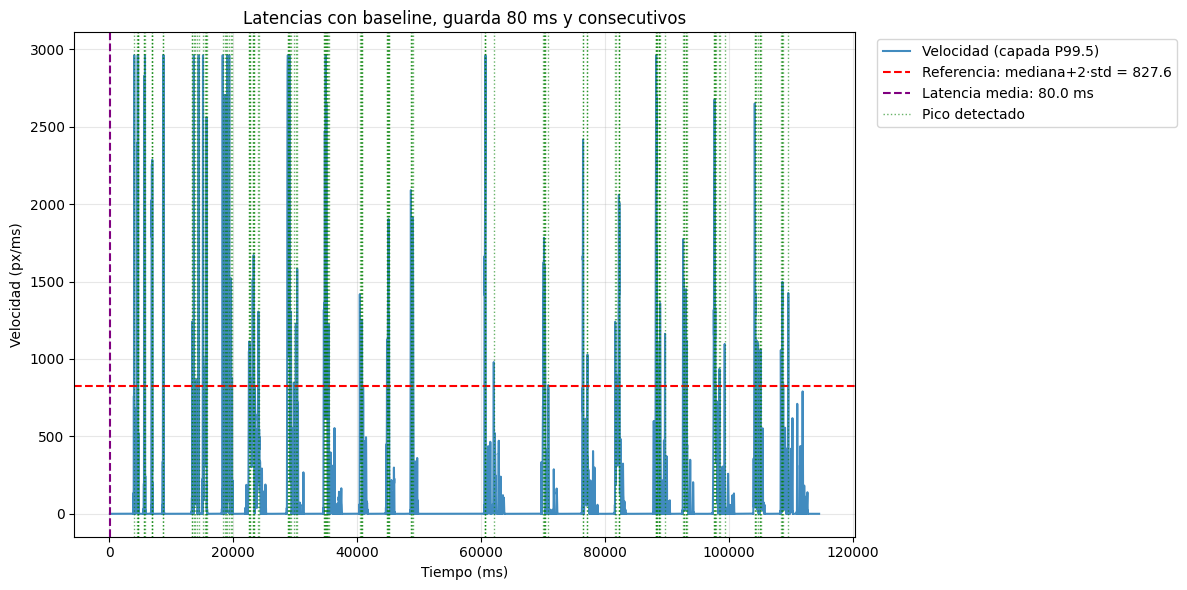

In [47]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

START = 100
END = rellenado.shape[0]

# --- Señal base (float64) ---
eyes_x = rellenado["eyes_x"].values.astype(np.float64)
eyes_y = rellenado["eyes_y"].values.astype(np.float64)

dis = distance(eyes_x, eyes_y)[1:-1].astype(np.float64)
vel = np.abs(differentiate(dis)).astype(np.float64)
vel = np.abs(denoise_35(vel)).astype(np.float64)

# --- CORTAR OUTLIERS por percentil 99.5 ---
CAP = np.percentile(vel, 99.5)
vel = np.clip(vel, None, CAP)

# --- Onsets (cambio de estímulo) ---
stim_x = rellenado["stimuli_x"].values
event_onsets = np.where(np.diff(stim_x) != 0)[0] + 1

# --- Tiempo ---
fs = 1000.0    # Hz
dt_ms = 1000.0 / fs
tiempo = np.arange(len(vel)) * dt_ms

# ===================== Latencia robusta =====================
BASELINE_MS   = 200     # ventana antes del onset para baseline
IGNORE_MS     = 80      # periodo de guarda tras onset (no detectar antes de esto)
MAX_LAT_MS    = 1200    # ventana máxima de búsqueda
MIN_CONSEC    = 3       # nº mínimo de muestras consecutivas sobre umbral
Z_NOISE       = 3.0     # k del baseline + k*std
BASE_PCTL_FLOOR = 95.0  # suelo del umbral = P95 del baseline

ignore_samp = int(round(IGNORE_MS / dt_ms))
base_samp   = int(round(BASELINE_MS / dt_ms))
max_samp    = int(round(MAX_LAT_MS / dt_ms))

latencias_ms = []
debug_info = []

for onset in event_onsets:
    if onset < base_samp:
        continue

    # 1) baseline y ruido previos
    base_seg = vel[onset - base_samp : onset]
    baseline = float(np.median(base_seg))
    noise    = float(np.std(base_seg, ddof=1))
    thr1     = baseline + Z_NOISE * noise
    thr2     = float(np.percentile(base_seg, BASE_PCTL_FLOOR))
    THR      = max(thr1, thr2)  # umbral final con suelo

    # 2) búsqueda tras periodo de guarda, acotada a MAX_LAT_MS
    start = onset + ignore_samp
    end   = min(len(vel), onset + max_samp)

    found = None
    if start < end and end - start >= MIN_CONSEC:
        # exige MIN_CONSEC consecutivas sobre umbral
        for i in range(start, end - MIN_CONSEC + 1):
            if np.all(vel[i:i+MIN_CONSEC] > THR):
                found = i
                break

    if found is not None:
        latencias_ms.append((found - onset) * dt_ms)

    # guarda algo de diagnóstico para los 3 primeros onsets
    if len(debug_info) < 3:
        debug_info.append({
            "onset": int(onset),
            "baseline_med": baseline,
            "baseline_std": noise,
            "thr_noise": thr1,
            "thr_pctl": thr2,
            "THR": THR,
            "max_0_500ms": float(np.max(vel[onset:onset+500])) if onset+500 <= len(vel) else float(np.max(vel[onset:])),
            "found_ms": float((found - onset) * dt_ms) if found is not None else None
        })

# --- Métricas globales ---
media_vel_general = float(np.mean(vel))
lat_mean_ms = float(np.mean(latencias_ms)) if latencias_ms else None

# --- Prints útiles ---
print(f"Cap aplicado (P99.5): {CAP:.1f}")
print(f"Onsets detectados: {len(event_onsets)}")
print(f"Latencias detectadas: {len(latencias_ms)}/{len(event_onsets)}")
if latencias_ms:
    print(f"Latencia media: {lat_mean_ms:.1f} ms")
    print(f"Desviación típica: {np.std(latencias_ms, ddof=1):.1f} ms")
print("\nDEBUG (primeros onsets):")
for d in debug_info:
    print(d)

# --- Umbral global (solo para la línea de referencia visual) ---
THRESHOLD_LINE = np.median(vel) + 2*np.std(vel)

# --- Picos (visual) ---
peaks, _ = find_peaks(vel, height=THRESHOLD_LINE)

# --- Gráfico ---
plt.figure(figsize=(12,6))
plt.plot(tiempo[START:END], vel[START:END], label="Velocidad (capada P99.5)", alpha=0.85)
plt.axhline(THRESHOLD_LINE, color="r", linestyle="--", linewidth=1.5,
            label=f"Referencia: mediana+2·std = {THRESHOLD_LINE:.1f}")

if lat_mean_ms is not None:
    plt.axvline(lat_mean_ms, color="purple", linestyle="--",
                label=f"Latencia media: {lat_mean_ms:.1f} ms")

labeled = False
for p in peaks:
    if START <= p < END:
        plt.axvline(tiempo[p], color='g', linestyle=':', alpha=0.6, linewidth=1,
                    label="Pico detectado" if not labeled else "")
        labeled = True

plt.title("Latencias con baseline, guarda 80 ms y consecutivos")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Velocidad (px/ms)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


INFO: CAP aplicado. Valores originales: max=45257.3, P99.9=6324.3
INFO: CAP=8387.4, ratio outlier=6.48
=== Diagnóstico ===
Outliers: P95=976.65, P99.9=6324.31, ratio=6.48 -> CAP aplicado: True (CAP=8387.4)
Lag estimado: 1285.0 ms -> corrección aplicada: True (lag usado: 1285.0 ms)
Onsets: 15 | Onsets corregidos: 15
Latencias detectadas: 15/15
Latencia media: 190.8 ms | SD: 252.1 ms
Rango: 30.0 - 688.0 ms

=== Debug primeros casos ===
Onset 0: baseline=8.1, THR=273.3, max_seg=1515.0, lat=31.0ms
Onset 1: baseline=0.0, THR=770.0, max_seg=3769.5, lat=124.0ms
Onset 2: baseline=0.0, THR=592.3, max_seg=3519.6, lat=63.0ms


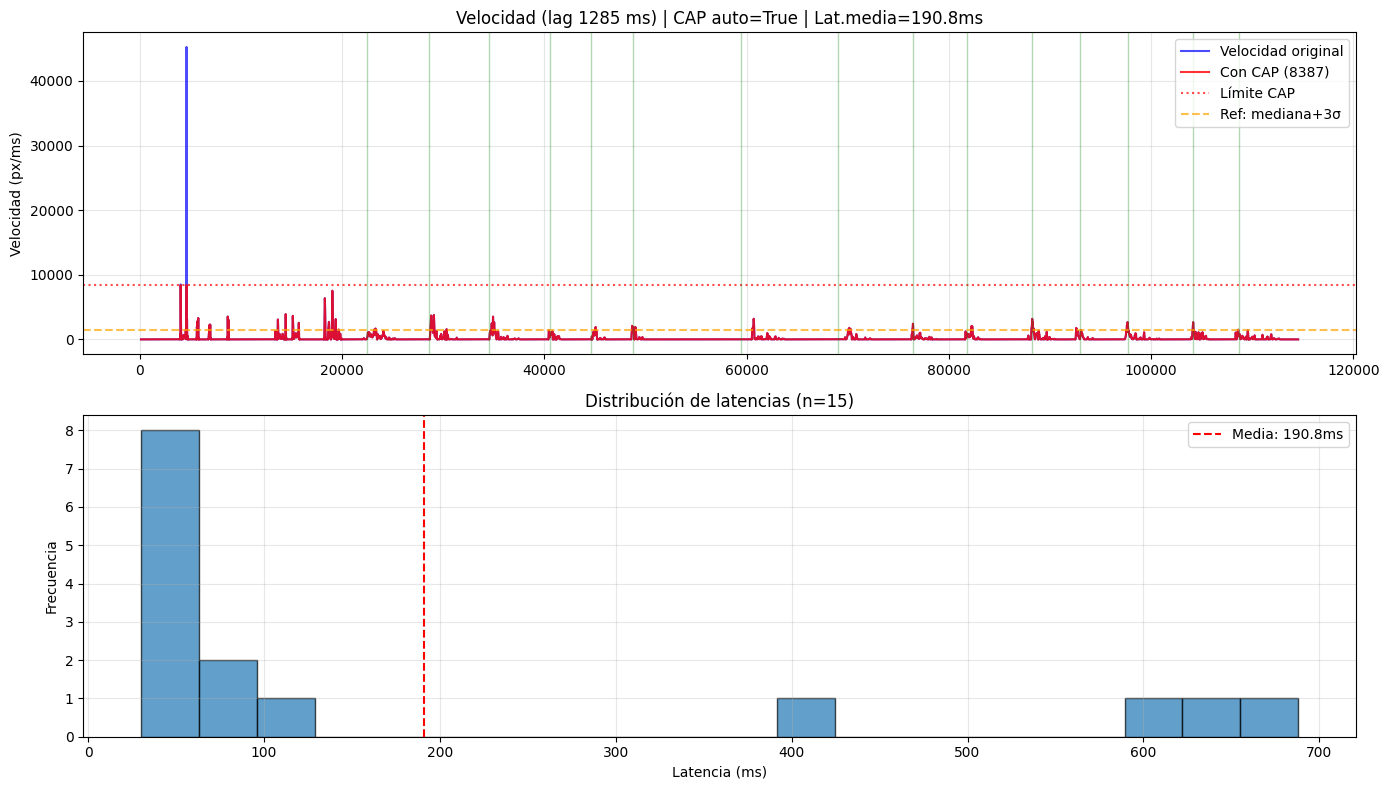


=== Impacto del CAP ===
Velocidad máxima original: 45257.3
Velocidad máxima con CAP: 8387.4
Reducción: 81.5%


In [48]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

# ================== Parámetros ==================
START = 100
END   = rellenado.shape[0]

FS = 1000.0
DT_MS = 1000.0 / FS

# Autopilotos
AUTO_LAG = True
AUTO_CAP = True

# Umbrales de decisión de autopilotos - AJUSTADOS
LAG_APPLY_MIN_MS = 600       
OUTLIER_RATIO    = 5.0       # Más conservador: de 4.0 a 6.0
CAP_PERCENTILE   = 99.95      # Más conservador: de 99.5 a 99.8

# Detección de latencia (tras posible corrección de onset)
BASELINE_MS = 200
IGNORE_MS   = 30
MAX_LAT_MS  = 800
MIN_CONSEC  = 2
FRAC_Q90    = 0.25           # Más conservador: de 0.30 a 0.25

# Estimación de lag
LAG_SEARCH_MS = 2000
SMOOTH_MS     = 50

# ================== Señal ==================
eyes_x = rellenado["eyes_x"].values.astype(np.float64)
eyes_y = rellenado["eyes_y"].values.astype(np.float64)

dis = distance(eyes_x, eyes_y)[1:-1].astype(np.float64)
vel = np.abs(differentiate(dis)).astype(np.float64)
vel = np.abs(denoise_35(vel)).astype(np.float64)

# ================== CAP más inteligente ==================
p95, p999 = np.percentile(vel, [95, 99.9])
outlier_ratio = p999 / max(p95, 1e-12)

# Solo aplicar CAP si hay outliers MUY extremos
do_cap = AUTO_CAP and (outlier_ratio >= OUTLIER_RATIO)

if do_cap:
    # CAP más conservador
    CAP = np.percentile(vel, CAP_PERCENTILE)
    vel_original = vel.copy()  # Guardar copia original
    vel = np.clip(vel, None, CAP)
    
    print(f"INFO: CAP aplicado. Valores originales: max={vel_original.max():.1f}, P99.9={p999:.1f}")
    print(f"INFO: CAP={CAP:.1f}, ratio outlier={outlier_ratio:.2f}")
else:
    CAP = None
    vel_original = vel.copy()

# ================== Onsets del estímulo ==================
stim_x = rellenado["stimuli_x"].values
event_onsets = np.where(np.diff(stim_x) != 0)[0] + 1
event_onsets = event_onsets[(event_onsets >= 0) & (event_onsets < len(vel))]

# ================== Estimar lag ==================
def moving_rms(x, w):
    if len(x) < w: 
        return x.copy()
    sw = sliding_window_view(x, w)
    rms = np.sqrt((sw**2).mean(axis=-1))
    pad_left = w//2
    pad_right = len(x) - len(rms) - pad_left
    return np.pad(rms, (pad_left, pad_right), mode='edge')

win = max(1, int(round(SMOOTH_MS / DT_MS)))

# USAR SEÑAL ORIGINAL para estimar lag (sin CAP)
env = moving_rms(vel_original, win)

imp = np.zeros(len(vel))
imp[event_onsets] = 1.0

imp_n = (imp - imp.mean()) / (imp.std() + 1e-12)
env_n = (env - env.mean()) / (env.std() + 1e-12)

xc = np.correlate(env_n, imp_n, mode='full')
lags = np.arange(-len(vel)+1, len(vel))
max_lag_samp = int(round(LAG_SEARCH_MS / DT_MS))
mask = (lags >= -max_lag_samp) & (lags <= max_lag_samp)
lags_short = lags[mask]; xc_short = xc[mask]

best_lag_samp = int(lags_short[np.argmax(xc_short)])
best_lag_ms = best_lag_samp * DT_MS

# Decisión de corrección
APPLY_LAG = AUTO_LAG and (best_lag_ms >= LAG_APPLY_MIN_MS)
lag_used_samp = best_lag_samp if APPLY_LAG else 0
lag_used_ms = lag_used_samp * DT_MS

event_onsets_corr = event_onsets + lag_used_samp
event_onsets_corr = event_onsets_corr[(event_onsets_corr >= 0) & (event_onsets_corr < len(vel))]

# ================== Latencias con umbrales más conservadores ==================
base_samp  = int(round(BASELINE_MS / DT_MS))
ignore_smp = int(round(IGNORE_MS   / DT_MS))
max_samp   = int(round(MAX_LAT_MS  / DT_MS))

latencias_ms = []
debug_info = []

for i, onset in enumerate(event_onsets_corr):
    if onset < base_samp: 
        continue

    # Calcular baseline con señal procesada (con CAP si aplica)
    base_seg = vel[onset - base_samp : onset]
    baseline = float(np.median(base_seg))
    noise    = float(np.std(base_seg, ddof=1))
    thr_noise = baseline + 3.0 * noise

    a = onset + ignore_smp
    b = min(len(vel), onset + max_samp)
    if a >= b:
        continue
    
    # CRÍTICO: usar señal procesada (con CAP) para detección
    seg = vel[a:b]
    if seg.size == 0:
        continue

    q90 = float(np.percentile(seg, 90))
    q95 = float(np.percentile(seg, 95))

    thr_frac = FRAC_Q90 * q90
    THR = max(thr_noise, thr_frac)
    THR = min(THR, q95)  # No sobrepases el P95 local

    found = None
    for j in range(a, b - MIN_CONSEC + 1):
        if np.all(vel[j:j+MIN_CONSEC] > THR):
            found = j
            break
    
    if found is not None:
        lat_ms = (found - onset) * DT_MS
        latencias_ms.append(lat_ms)
        
        # Info de debug para los primeros casos
        if i < 3:
            debug_info.append({
                'onset': i,
                'baseline': baseline,
                'thr_noise': thr_noise,
                'q90': q90,
                'q95': q95,
                'THR': THR,
                'latencia': lat_ms,
                'max_seg': seg.max()
            })

# ================== Resultados ==================
media_vel_general = float(np.mean(vel))
lat_mean_ms = float(np.mean(latencias_ms)) if latencias_ms else None

print("=== Diagnóstico ===")
print(f"Outliers: P95={p95:.2f}, P99.9={p999:.2f}, ratio={outlier_ratio:.2f} -> CAP aplicado: {do_cap}" + (f" (CAP={CAP:.1f})" if do_cap else ""))
print(f"Lag estimado: {best_lag_ms:.1f} ms -> corrección aplicada: {APPLY_LAG} (lag usado: {lag_used_ms:.1f} ms)")
print(f"Onsets: {len(event_onsets)} | Onsets corregidos: {len(event_onsets_corr)}")
print(f"Latencias detectadas: {len(latencias_ms)}/{len(event_onsets_corr)}")

if latencias_ms:
    print(f"Latencia media: {lat_mean_ms:.1f} ms | SD: {np.std(latencias_ms, ddof=1):.1f} ms")
    print(f"Rango: {min(latencias_ms):.1f} - {max(latencias_ms):.1f} ms")

# Debug de primeros casos
if debug_info:
    print("\n=== Debug primeros casos ===")
    for info in debug_info:
        print(f"Onset {info['onset']}: baseline={info['baseline']:.1f}, THR={info['THR']:.1f}, "
              f"max_seg={info['max_seg']:.1f}, lat={info['latencia']:.1f}ms")

# ================== Gráfico ==================
t_ms = np.arange(len(vel)) * DT_MS
plt.figure(figsize=(14,8))

# Subplot 1: Señal completa
plt.subplot(2,1,1)
plt.plot(t_ms[START:END], vel_original[START:END], 'b-', alpha=0.7, label="Velocidad original")
if do_cap:
    plt.plot(t_ms[START:END], vel[START:END], 'r-', alpha=0.8, label=f"Con CAP ({CAP:.0f})")
    plt.axhline(CAP, color="red", linestyle=":", alpha=0.7, label=f"Límite CAP")

# Marcar onsets
for onset in event_onsets_corr[event_onsets_corr >= START]:
    if onset < END:
        plt.axvline(onset * DT_MS, color="green", alpha=0.3, linewidth=1)

if lat_mean_ms is not None:
    plt.axhline(np.median(vel) + 3*np.std(vel), color="orange", linestyle="--", 
                alpha=0.7, label="Ref: mediana+3σ")

title_lag = f"(lag {lag_used_ms:.0f} ms)" if APPLY_LAG else "(sin lag)"
plt.title(f"Velocidad {title_lag} | CAP auto={do_cap} | Lat.media={lat_mean_ms:.1f}ms")
plt.ylabel("Velocidad (px/ms)")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Histograma de latencias
plt.subplot(2,1,2)
if latencias_ms:
    plt.hist(latencias_ms, bins=20, alpha=0.7, edgecolor='black')
    plt.axvline(lat_mean_ms, color="red", linestyle="--", 
                label=f"Media: {lat_mean_ms:.1f}ms")
    plt.xlabel("Latencia (ms)")
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución de latencias (n={len(latencias_ms)})")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparación antes/después si se aplicó CAP
if do_cap:
    print(f"\n=== Impacto del CAP ===")
    print(f"Velocidad máxima original: {vel_original.max():.1f}")
    print(f"Velocidad máxima con CAP: {vel.max():.1f}")
    print(f"Reducción: {((vel_original.max() - vel.max()) / vel_original.max() * 100):.1f}%")

# CODIGO PRUEBA (EJECUTA ESTE ROBERTO)

🔍 ANÁLISIS DE OUTLIERS
   P95=976.7, P99.9=6324.3, Max=45257
   Ratio outlier: 6.48
   Spikes (Extremos) detectados con umbral > P99.9*3 (18973): 41
🎯 DECISIÓN: Artefactos extremos detectados. CAP suave (P99.9) aplicado.
   Límite CAP: 6324.3

📊 RESULTADOS FINALES
Velocidad media original: 165.34 ± 837.15 px/ms
Velocidad media con CAP: 153.71 px/ms
Reducción en media: 7.03%
Lag estimado: 1285.0 ms -> aplicado: True (usado: 1285.0 ms)
Onsets: 15 | Onsets corregidos: 15
Latencias detectadas: 15/15
Latencia media: 190.8 ms ± 252.1 ms
Rango: 30.0 - 688.0 ms


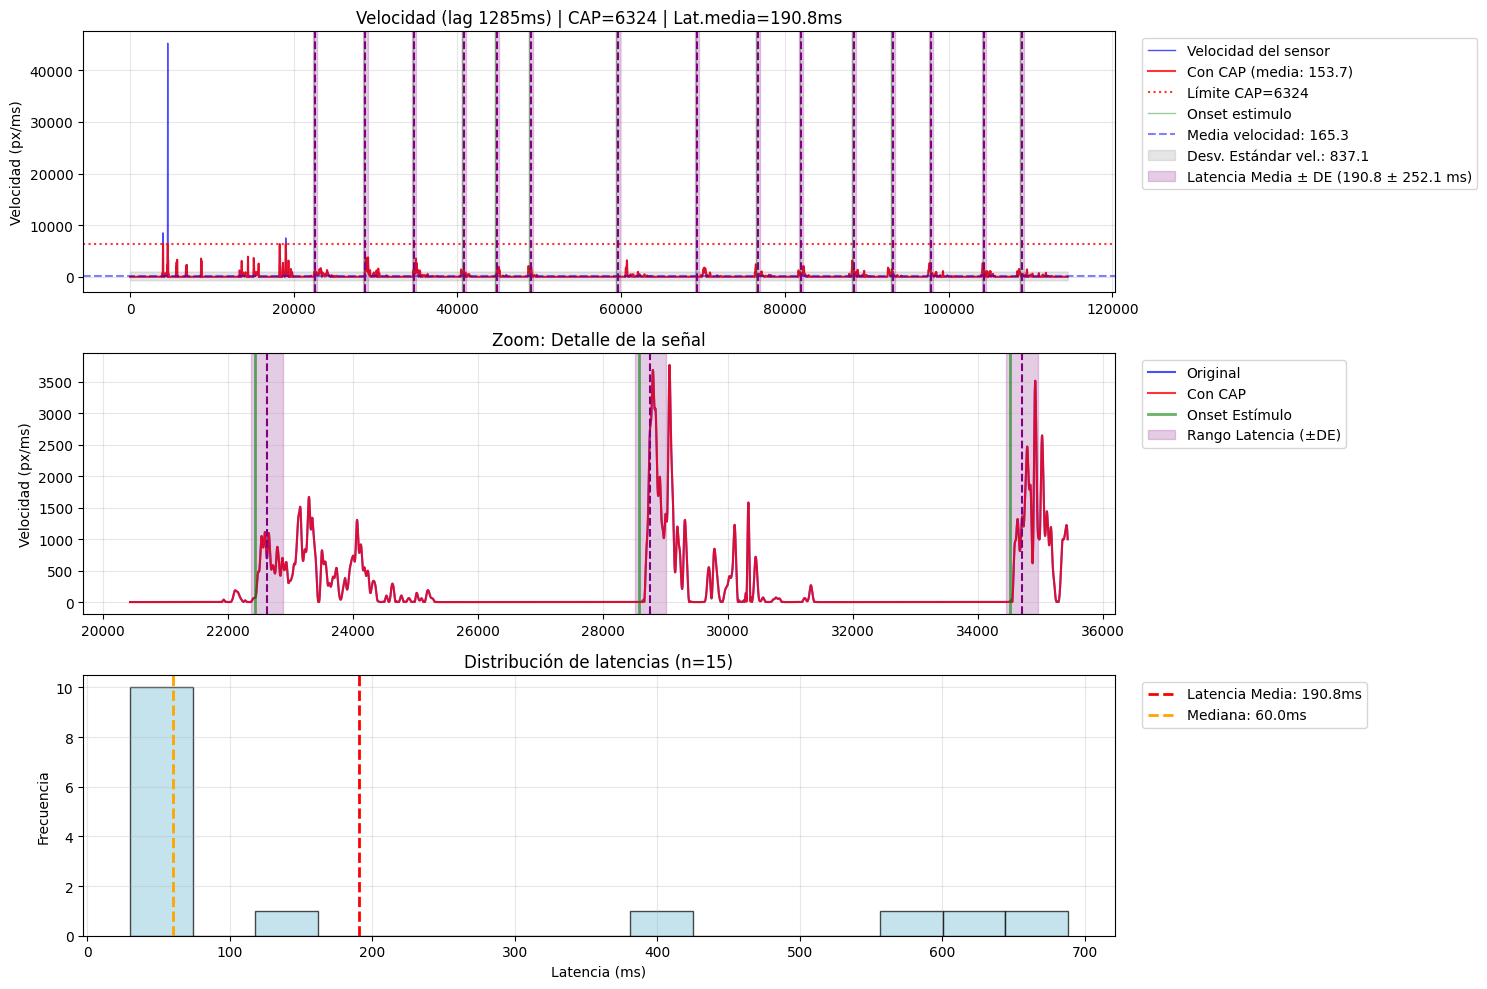


⚡ IMPACTO DEL CAP:
Máximo original: 45257 → Máximo con CAP: 6324
Reducción máxima: 86.0%
Puntos cappados: 115 (0.1004%)


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
from scipy.signal import find_peaks

# ================== Parámetros ==================
START = 0
END   = len(vel)

FS = 1000.0
DT_MS = 1000.0 / FS

# Autopilotos
AUTO_LAG = True
AUTO_CAP = True

# Umbrales de decisión de autopilotos
LAG_APPLY_MIN_MS = 600       
OUTLIER_RATIO    = 5.0       # Umbral para activar análisis de CAP

# Detección de latencia
BASELINE_MS = 200
IGNORE_MS   = 30
MAX_LAT_MS  = 800
MIN_CONSEC  = 2
FRAC_Q90    = 0.25            

# Estimación de lag
LAG_SEARCH_MS = 2000
SMOOTH_MS     = 50

# ================== Señal ==================
# Nota: Asegúrate de que las funciones distance(), differentiate() y denoise_35() 
# estén definidas en alguna parte de tu entorno de ejecución.
eyes_x = rellenado["eyes_x"].values.astype(np.float64)
eyes_y = rellenado["eyes_y"].values.astype(np.float64)

dis = distance(eyes_x, eyes_y)[1:-1].astype(np.float64)
vel = np.abs(differentiate(dis)).astype(np.float64)
vel = np.abs(denoise_35(vel)).astype(np.float64)

# ================== CAP Inteligente (Versión Final y Definitiva) ==================
p95, p999 = np.percentile(vel, [95, 99.9])
outlier_ratio = p999 / max(p95, 1e-12)
vel_original = vel.copy()  # Guardar copia original

print(f"🔍 ANÁLISIS DE OUTLIERS")
print(f"   P95={p95:.1f}, P99.9={p999:.1f}, Max={vel.max():.0f}")
print(f"   Ratio outlier: {outlier_ratio:.2f}")

# Decisión de CAP
do_cap = False
CAP = None

# --- LÓGICA DE DETECCIÓN FINAL ---
spike_threshold = p999 * 3.0
spike_indices = np.where(vel > spike_threshold)[0]
n_spikes = len(spike_indices)

print(f"   Spikes (Extremos) detectados con umbral > P99.9*3 ({spike_threshold:.0f}): {n_spikes}")

if n_spikes > 0:
    CAP = p999
    cap_type = "suave (P99.9)"
    vel = np.clip(vel, None, CAP)
    do_cap = True
    print(f"🎯 DECISIÓN: Artefactos extremos detectados. CAP {cap_type} aplicado.")
    print(f"   Límite CAP: {CAP:.1f}")
else:
    print(f"🎯 DECISIÓN: No se detectaron artefactos extremos. No se aplica CAP.")

# ================== Onsets del estímulo ==================
stim_x = rellenado["stimuli_x"].values
event_onsets = np.where(np.diff(stim_x) != 0)[0] + 1
event_onsets = event_onsets[(event_onsets >= 0) & (event_onsets < len(vel))]

# ================== Estimar lag ==================
def moving_rms(x, w):
    if len(x) < w: return x.copy()
    sw = sliding_window_view(x, w); rms = np.sqrt((sw**2).mean(axis=-1))
    pad_left = w//2; pad_right = len(x) - len(rms) - pad_left
    return np.pad(rms, (pad_left, pad_right), mode='edge')

win = max(1, int(round(SMOOTH_MS / DT_MS)))
env = moving_rms(vel_original, win)
imp = np.zeros(len(vel)); imp[event_onsets] = 1.0
imp_n = (imp - imp.mean()) / (imp.std() + 1e-12); env_n = (env - env.mean()) / (env.std() + 1e-12)
xc = np.correlate(env_n, imp_n, mode='full'); lags = np.arange(-len(vel)+1, len(vel))
max_lag_samp = int(round(LAG_SEARCH_MS / DT_MS))
mask = (lags >= -max_lag_samp) & (lags <= max_lag_samp)
lags_short = lags[mask]; xc_short = xc[mask]
best_lag_samp = int(lags_short[np.argmax(xc_short)])
best_lag_ms = best_lag_samp * DT_MS
APPLY_LAG = AUTO_LAG and (best_lag_ms >= LAG_APPLY_MIN_MS)
lag_used_samp = best_lag_samp if APPLY_LAG else 0
lag_used_ms = lag_used_samp * DT_MS
event_onsets_corr = event_onsets + lag_used_samp
event_onsets_corr = event_onsets_corr[(event_onsets_corr >= 0) & (event_onsets_corr < len(vel))]

# ================== Detección de latencias ==================
base_samp  = int(round(BASELINE_MS / DT_MS)); ignore_smp = int(round(IGNORE_MS   / DT_MS))
max_samp   = int(round(MAX_LAT_MS  / DT_MS)); latencias_ms = []; debug_info = []

for i, onset in enumerate(event_onsets_corr):
    if onset < base_samp: continue
    base_seg = vel[onset - base_samp : onset]; baseline = float(np.median(base_seg))
    noise = float(np.std(base_seg, ddof=1)); thr_noise = baseline + 3.0 * noise
    a = onset + ignore_smp; b = min(len(vel), onset + max_samp)
    if a >= b: continue
    seg = vel[a:b]
    if seg.size == 0: continue
    q90 = float(np.percentile(seg, 90)); q95 = float(np.percentile(seg, 95))
    thr_frac = FRAC_Q90 * q90; THR = max(thr_noise, thr_frac); THR = min(THR, q95)
    found = None
    for j in range(a, b - MIN_CONSEC + 1):
        if np.all(vel[j:j+MIN_CONSEC] > THR): found = j; break
    if found is not None:
        lat_ms = (found - onset) * DT_MS; latencias_ms.append(lat_ms)

# ================== Resultados ==================
media_vel_cap = float(np.mean(vel))
media_vel_original = float(np.mean(vel_original))
std_vel_original = float(np.std(vel_original, ddof=1)) # Desviación estándar de la velocidad
lat_mean_ms = float(np.mean(latencias_ms)) if latencias_ms else None
lat_std_ms = float(np.std(latencias_ms, ddof=1)) if latencias_ms else None # Desviación estándar de la latencia

print(f"\n📊 RESULTADOS FINALES")
print(f"Velocidad media original: {media_vel_original:.2f} ± {std_vel_original:.2f} px/ms")
if do_cap:
    print(f"Velocidad media con CAP: {media_vel_cap:.2f} px/ms")
    reduction = ((media_vel_original - media_vel_cap) / media_vel_original) * 100
    print(f"Reducción en media: {reduction:.2f}%")

print(f"Lag estimado: {best_lag_ms:.1f} ms -> aplicado: {APPLY_LAG} (usado: {lag_used_ms:.1f} ms)")
print(f"Onsets: {len(event_onsets)} | Onsets corregidos: {len(event_onsets_corr)}")
print(f"Latencias detectadas: {len(latencias_ms)}/{len(event_onsets_corr)}")

if latencias_ms:
    print(f"Latencia media: {lat_mean_ms:.1f} ms ± {lat_std_ms:.1f} ms")
    print(f"Rango: {min(latencias_ms):.1f} - {max(latencias_ms):.1f} ms")

# ================== Gráfico ==================
t_ms = np.arange(len(vel)) * DT_MS
plt.figure(figsize=(15,10))

# --- Subplot 1: Señal completa ---
ax1 = plt.subplot(3,1,1)
ax1.plot(t_ms[START:END], vel_original[START:END], 'b-', alpha=0.7, linewidth=1, label="Velocidad del sensor")

if do_cap:
    ax1.plot(t_ms[START:END], vel[START:END], 'r-', alpha=0.8, linewidth=1.5, label=f"Con CAP (media: {media_vel_cap:.1f})")
    ax1.axhline(CAP, color="red", linestyle=":", alpha=0.8, label=f"Límite CAP={CAP:.0f}")

# Marcar onsets corregidos
label_onset = "Onset estimulo"
for onset in event_onsets_corr:
    if START <= onset < END:
        ax1.axvline(onset * DT_MS, color="green", alpha=0.4, linewidth=1, label = label_onset)
        label_onset = None  # Solo una etiqueta en la leyenda

# BANDA DE DESVIACIÓN ESTÁNDAR DE LA VELOCIDAD
ax1.axhline(media_vel_original, color="blue", linestyle="--", alpha=0.5, label=f"Media velocidad: {media_vel_original:.1f}")
ax1.fill_between(t_ms[START:END], media_vel_original - std_vel_original, media_vel_original + std_vel_original,
                 color='grey', alpha=0.2, label=f"Desv. Estándar vel.: {std_vel_original:.1f}")

# BANDA DE DESVIACIÓN ESTÁNDAR DE LA LATENCIA
if lat_mean_ms is not None and lat_std_ms is not None:
    label_lat = f"Latencia Media ± DE ({lat_mean_ms:.1f} ± {lat_std_ms:.1f} ms)"
    for onset in event_onsets_corr:
        if START <= onset < END:
            onset_ms = onset * DT_MS
            ax1.axvspan(onset_ms + lat_mean_ms - lat_std_ms,
                        onset_ms + lat_mean_ms + lat_std_ms,
                        color='purple', alpha=0.2, label=label_lat)
            ax1.axvline(x=onset_ms + lat_mean_ms, color='purple', linestyle='--')
            label_lat = None

# Título y Leyenda Subplot 1
title_lag = f"(lag {lag_used_ms:.0f}ms)" if APPLY_LAG else "(sin lag)"
cap_info = f"CAP={CAP:.0f}" if do_cap else "sin CAP"
ax1.set_title(f"Velocidad {title_lag} | {cap_info} | Lat.media={lat_mean_ms:.1f}ms")
ax1.set_ylabel("Velocidad (px/ms)")
handles, labels = ax1.get_legend_handles_labels(); by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc="upper left")
ax1.grid(True, alpha=0.3)

# --- Subplot 2: Zoom en una región con actividad (CORREGIDO) ---
ax2 = plt.subplot(3,1,2)

# --- INICIO DE LA MODIFICACIÓN ---
# Hacer que la ventana de zoom sea dinámica y se centre en el primer estímulo
if len(event_onsets_corr) > 0:
    # Encontrar el primer onset que ocurre después de START
    onsets_visibles = event_onsets_corr[event_onsets_corr >= START]
    if len(onsets_visibles) > 0:
        primer_onset = onsets_visibles[0]
        # Centrar el zoom 2 segundos antes del primer onset visible
        zoom_start = max(START, primer_onset - int(2000/DT_MS))
        zoom_end = min(END, zoom_start + int(15000/DT_MS)) # Ventana de 15 seg
    else: # Caso de seguridad si no hay onsets visibles
        zoom_start = max(START, int(5000/DT_MS))
        zoom_end = min(END, zoom_start + int(10000/DT_MS))
else: # Caso de seguridad si no hay onsets en absoluto
    zoom_start = max(START, int(5000/DT_MS))
    zoom_end = min(END, zoom_start + int(10000/DT_MS))
# --- FIN DE LA MODIFICACIÓN ---


ax2.plot(t_ms[zoom_start:zoom_end], vel_original[zoom_start:zoom_end], 'b-', alpha=0.7, label="Original")
if do_cap:
    ax2.plot(t_ms[zoom_start:zoom_end], vel[zoom_start:zoom_end], 'r-', alpha=0.8, label="Con CAP")

# Marcar onsets y latencias en zoom
if lat_mean_ms is not None and lat_std_ms is not None:
    label_onset = "Onset Estímulo"; label_lat_band = "Rango Latencia (±DE)"
    for onset in event_onsets_corr:
        if zoom_start <= onset < zoom_end:
            onset_ms = onset * DT_MS
            ax2.axvline(onset_ms, color="green", alpha=0.6, linewidth=2, label=label_onset)
            ax2.axvspan(onset_ms + lat_mean_ms - lat_std_ms,
                        onset_ms + lat_mean_ms + lat_std_ms,
                        color='purple', alpha=0.2, label=label_lat_band)
            ax2.axvline(x=onset_ms + lat_mean_ms, color='purple', linestyle='--')
            label_onset = None; label_lat_band = None

ax2.set_title("Zoom: Detalle de la señal")
ax2.set_ylabel("Velocidad (px/ms)")
# Usar truco para evitar etiquetas duplicadas en la leyenda
handles, labels = ax2.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax2.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc="upper left")
ax2.grid(True, alpha=0.3)

# --- Subplot 3: Histograma de latencias ---
ax3 = plt.subplot(3,1,3)
if latencias_ms:
    ax3.hist(latencias_ms, bins=min(20, len(latencias_ms)), alpha=0.7, edgecolor='black', color='lightblue')
    ax3.axvline(lat_mean_ms, color="red", linestyle="--", linewidth=2, label=f"Latencia Media: {lat_mean_ms:.1f}ms")
    ax3.axvline(np.median(latencias_ms), color="orange", linestyle="--", linewidth=2, label=f"Mediana: {np.median(latencias_ms):.1f}ms")
    ax3.set_xlabel("Latencia (ms)")
    ax3.set_ylabel("Frecuencia")
    ax3.set_title(f"Distribución de latencias (n={len(latencias_ms)})")
    ax3.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis final del impacto del CAP
if do_cap:
    original_max = vel_original.max(); capped_max = vel.max()
    max_reduction = ((original_max - capped_max) / original_max) * 100
    capped_count = np.sum(vel_original > CAP)
    capped_pct = (capped_count / len(vel_original)) * 100
    print(f"\n⚡ IMPACTO DEL CAP:")
    print(f"Máximo original: {original_max:.0f} → Máximo con CAP: {capped_max:.0f}")
    print(f"Reducción máxima: {max_reduction:.1f}%")
    print(f"Puntos cappados: {capped_count} ({capped_pct:.4f}%)")

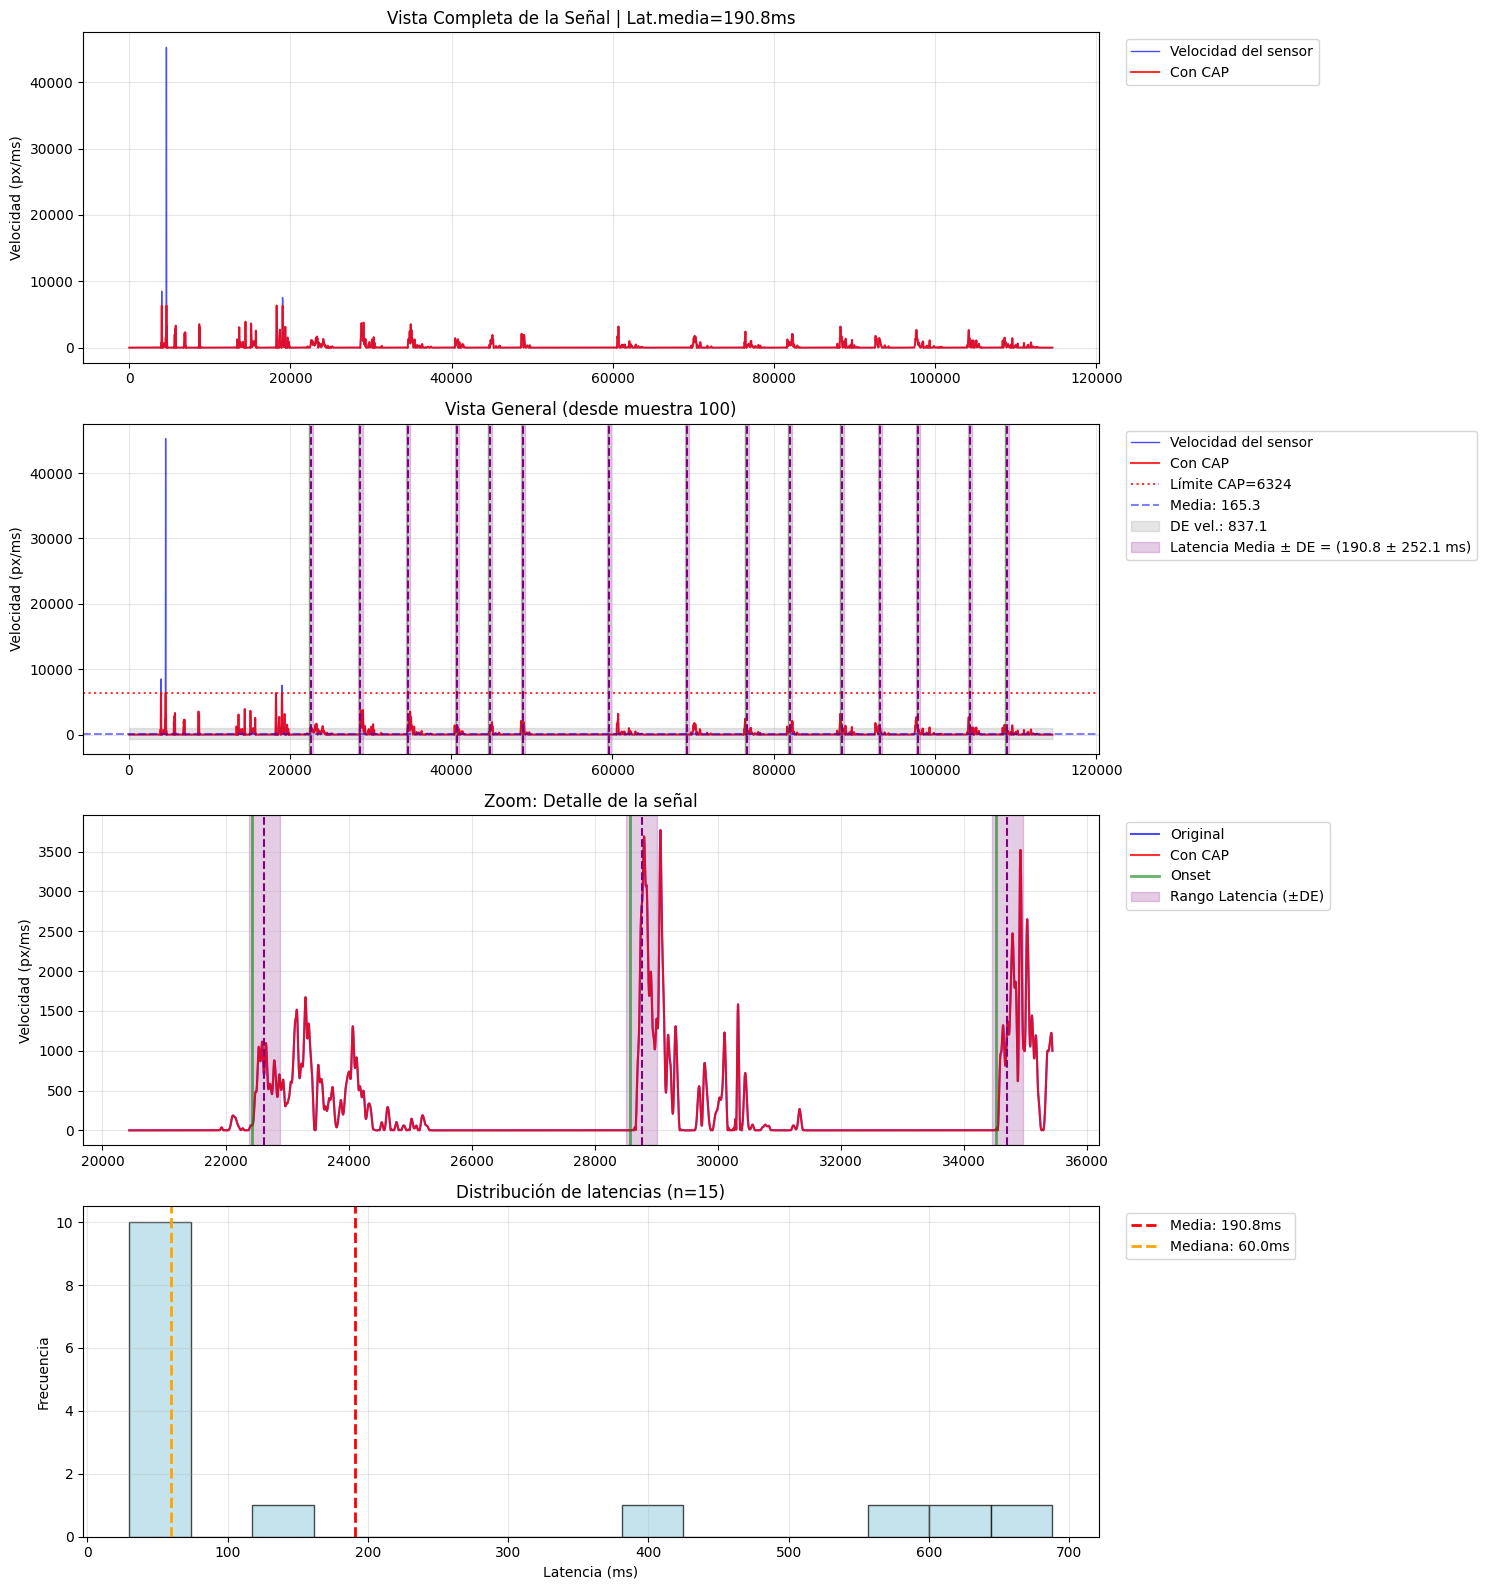

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
from scipy.signal import find_peaks

# ================== Parámetros ==================
# Rango para el análisis y el primer gráfico (toda la señal)
START = 0
END   = rellenado.shape[0]

FS = 1000.0
DT_MS = 1000.0 / FS

# ... (resto de tus parámetros no necesitan cambios) ...
# Autopilotos
AUTO_LAG = True
AUTO_CAP = True
LAG_APPLY_MIN_MS = 600       
OUTLIER_RATIO    = 5.0
# Detección de latencia
BASELINE_MS = 200
IGNORE_MS   = 30
MAX_LAT_MS  = 800
MIN_CONSEC  = 2
FRAC_Q90    = 0.25
# Estimación de lag
LAG_SEARCH_MS = 2000
SMOOTH_MS     = 50


# ================== Señal ==================
eyes_x = rellenado["eyes_x"].values.astype(np.float64)
eyes_y = rellenado["eyes_y"].values.astype(np.float64)
dis = distance(eyes_x, eyes_y)[1:-1].astype(np.float64)
vel = np.abs(differentiate(dis)).astype(np.float64)
vel = np.abs(denoise_35(vel)).astype(np.float64)


# ================== CAP Inteligente (Versión Final y Definitiva) ==================
p95, p999 = np.percentile(vel, [95, 99.9])
outlier_ratio = p999 / max(p95, 1e-12)
vel_original = vel.copy()
do_cap = False
CAP = None
spike_threshold = p999 * 3.0
spike_indices = np.where(vel > spike_threshold)[0]
n_spikes = len(spike_indices)
if n_spikes > 0:
    CAP = p999
    vel = np.clip(vel, None, CAP)
    do_cap = True

# ================== Onsets del estímulo ==================
stim_x = rellenado["stimuli_x"].values
event_onsets = np.where(np.diff(stim_x) != 0)[0] + 1
event_onsets = event_onsets[(event_onsets >= 0) & (event_onsets < len(vel))]


# ================== Estimar lag ==================
def moving_rms(x, w):
    if len(x) < w: return x.copy()
    sw = sliding_window_view(x, w); rms = np.sqrt((sw**2).mean(axis=-1))
    pad_left = w//2; pad_right = len(x) - len(rms) - pad_left
    return np.pad(rms, (pad_left, pad_right), mode='edge')
win = max(1, int(round(SMOOTH_MS / DT_MS)))
env = moving_rms(vel_original, win)
imp = np.zeros(len(vel)); imp[event_onsets] = 1.0
imp_n = (imp - imp.mean()) / (imp.std() + 1e-12); env_n = (env - env.mean()) / (env.std() + 1e-12)
xc = np.correlate(env_n, imp_n, mode='full'); lags = np.arange(-len(vel)+1, len(vel))
max_lag_samp = int(round(LAG_SEARCH_MS / DT_MS))
mask = (lags >= -max_lag_samp) & (lags <= max_lag_samp)
lags_short = lags[mask]; xc_short = xc[mask]
best_lag_samp = int(lags_short[np.argmax(xc_short)])
best_lag_ms = best_lag_samp * DT_MS
APPLY_LAG = AUTO_LAG and (best_lag_ms >= LAG_APPLY_MIN_MS)
lag_used_samp = best_lag_samp if APPLY_LAG else 0
lag_used_ms = lag_used_samp * DT_MS
event_onsets_corr = event_onsets + lag_used_samp
event_onsets_corr = event_onsets_corr[(event_onsets_corr >= 0) & (event_onsets_corr < len(vel))]


# ================== Detección de latencias ==================
base_samp  = int(round(BASELINE_MS / DT_MS)); ignore_smp = int(round(IGNORE_MS   / DT_MS))
max_samp   = int(round(MAX_LAT_MS  / DT_MS)); latencias_ms = []
for i, onset in enumerate(event_onsets_corr):
    if onset < base_samp: continue
    base_seg = vel[onset - base_samp : onset]; baseline = float(np.median(base_seg))
    noise = float(np.std(base_seg, ddof=1)); thr_noise = baseline + 3.0 * noise
    a = onset + ignore_smp; b = min(len(vel), onset + max_samp)
    if a >= b: continue
    seg = vel[a:b]
    if seg.size == 0: continue
    q90 = float(np.percentile(seg, 90)); q95 = float(np.percentile(seg, 95))
    thr_frac = FRAC_Q90 * q90; THR = max(thr_noise, thr_frac); THR = min(THR, q95)
    found = None
    for j in range(a, b - MIN_CONSEC + 1):
        if np.all(vel[j:j+MIN_CONSEC] > THR): found = j; break
    if found is not None:
        lat_ms = (found - onset) * DT_MS; latencias_ms.append(lat_ms)


# ================== Resultados ==================
media_vel_cap = float(np.mean(vel))
media_vel_original = float(np.mean(vel_original))
std_vel_original = float(np.std(vel_original, ddof=1))
lat_mean_ms = float(np.mean(latencias_ms)) if latencias_ms else None
lat_std_ms = float(np.std(latencias_ms, ddof=1)) if latencias_ms else None


# ================== Gráfico con 4 Subplots ==================
t_ms = np.arange(len(vel)) * DT_MS
plt.figure(figsize=(15, 16)) # Figura más alta para que quepan 4 gráficos

# --- Subplot 1: Señal COMPLETA (desde 0) ---
ax1 = plt.subplot(4, 1, 1)
ax1.plot(t_ms[START:END], vel_original[START:END], 'b-', alpha=0.7, linewidth=1, label="Velocidad del sensor")
if do_cap:
    ax1.plot(t_ms[START:END], vel[START:END], 'r-', alpha=0.8, linewidth=1.5, label=f"Con CAP")
ax1.set_title(f"Vista Completa de la Señal | Lat.media={lat_mean_ms:.1f}ms")
ax1.set_ylabel("Velocidad (px/ms)")
ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax1.grid(True, alpha=0.3)


# --- Subplot 2: NUEVO - Vista Parcial (desde 100) ---
ax2 = plt.subplot(4, 1, 2)
VIEW_START = 100
VIEW_END = rellenado.shape[0]
VIEW_END = min(VIEW_END, len(t_ms)) # Seguridad

ax2.plot(t_ms[VIEW_START:VIEW_END], vel_original[VIEW_START:VIEW_END], 'b-', alpha=0.7, linewidth=1, label="Velocidad del sensor")
if do_cap:
    ax2.plot(t_ms[VIEW_START:VIEW_END], vel[VIEW_START:VIEW_END], 'r-', alpha=0.8, linewidth=1.5, label=f"Con CAP")
    ax2.axhline(CAP, color="red", linestyle=":", alpha=0.8, label=f"Límite CAP={CAP:.0f}")
for onset in event_onsets_corr:
    if VIEW_START <= onset < VIEW_END:
        ax2.axvline(onset * DT_MS, color="green", alpha=0.4, linewidth=1)
ax2.axhline(media_vel_original, color="blue", linestyle="--", alpha=0.5, label=f"Media: {media_vel_original:.1f}")
ax2.fill_between(t_ms[VIEW_START:VIEW_END], media_vel_original - std_vel_original, media_vel_original + std_vel_original,
                 color='grey', alpha=0.2, label=f"DE vel.: {std_vel_original:.1f}")
if lat_mean_ms is not None and lat_std_ms is not None:
    label_lat = f"Latencia Media ± DE = ({lat_mean_ms:.1f} ± {lat_std_ms:.1f} ms)"
    for onset in event_onsets_corr:
        if VIEW_START <= onset < VIEW_END:
            onset_ms = onset * DT_MS
            ax2.axvspan(onset_ms + lat_mean_ms - lat_std_ms, onset_ms + lat_mean_ms + lat_std_ms,
                        color='purple', alpha=0.2, label=label_lat)
            ax2.axvline(x=onset_ms + lat_mean_ms, color='purple', linestyle='--')
            label_lat = None
ax2.set_title(f"Vista General (desde muestra 100)")
ax2.set_ylabel("Velocidad (px/ms)")
handles, labels = ax2.get_legend_handles_labels(); by_label = dict(zip(labels, handles))
ax2.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc="upper left")
ax2.grid(True, alpha=0.3)


# --- Subplot 3: Zoom dinámico ---
ax3 = plt.subplot(4, 1, 3)
if len(event_onsets_corr) > 0:
    onsets_visibles = event_onsets_corr[event_onsets_corr >= START]
    if len(onsets_visibles) > 0:
        primer_onset = onsets_visibles[0]
        zoom_start = max(START, primer_onset - int(2000/DT_MS))
        zoom_end = min(END, zoom_start + int(15000/DT_MS))
    else:
        zoom_start = max(START, int(5000/DT_MS)); zoom_end = min(END, zoom_start + int(10000/DT_MS))
else:
    zoom_start = max(START, int(5000/DT_MS)); zoom_end = min(END, zoom_start + int(10000/DT_MS))

ax3.plot(t_ms[zoom_start:zoom_end], vel_original[zoom_start:zoom_end], 'b-', alpha=0.7, label="Original")
if do_cap:
    ax3.plot(t_ms[zoom_start:zoom_end], vel[zoom_start:zoom_end], 'r-', alpha=0.8, label="Con CAP")
if lat_mean_ms is not None and lat_std_ms is not None:
    label_onset = "Onset"; label_lat_band = "Rango Latencia (±DE)"
    for onset in event_onsets_corr:
        if zoom_start <= onset < zoom_end:
            onset_ms = onset * DT_MS
            ax3.axvline(onset_ms, color="green", alpha=0.6, linewidth=2, label=label_onset)
            ax3.axvspan(onset_ms + lat_mean_ms - lat_std_ms, onset_ms + lat_mean_ms + lat_std_ms,
                        color='purple', alpha=0.2, label=label_lat_band)
            ax3.axvline(x=onset_ms + lat_mean_ms, color='purple', linestyle='--')
            label_onset = None; label_lat_band = None
ax3.set_title("Zoom: Detalle de la señal")
ax3.set_ylabel("Velocidad (px/ms)")
handles, labels = ax3.get_legend_handles_labels(); by_label = dict(zip(labels, handles))
ax3.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc="upper left")
ax3.grid(True, alpha=0.3)


# --- Subplot 4: Histograma de latencias ---
ax4 = plt.subplot(4, 1, 4)
if latencias_ms:
    ax4.hist(latencias_ms, bins=min(20, len(latencias_ms)), alpha=0.7, edgecolor='black', color='lightblue')
    ax4.axvline(lat_mean_ms, color="red", linestyle="--", linewidth=2, label=f"Media: {lat_mean_ms:.1f}ms")
    ax4.axvline(np.median(latencias_ms), color="orange", linestyle="--", linewidth=2, label=f"Mediana: {np.median(latencias_ms):.1f}ms")
    ax4.set_xlabel("Latencia (ms)")
    ax4.set_ylabel("Frecuencia")
    ax4.set_title(f"Distribución de latencias (n={len(latencias_ms)})")
    ax4.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

CAMBIOS

1. UMBRAL FIJO
Umbral = 1000

¿Por qué fallaba?

Tu señal tenía velocidad media = 161 y máxima = 31,579
Un umbral de 1000 era demasiado alto para detectar movimientos normales pero demasiado bajo para evitar ruido esporádico
Resultado: O no detectaba nada, o detectaba picos aislados de ruido

¿Cómo lo solucionó el percentil 95?

Encuentra automáticamente el valor que solo el 5% de puntos supera
Eso corresponde a movimientos reales (sacadas oculares), no ruido
Se adapta automáticamente a cada dataset


2. PROBLEMA: Búsqueda infinita sin límites
❌ Antes:
pythonwhile i < len(vel) - min_samples:  # Busca hasta el final del archivo
    if vel[i] > THRESHOLD:
        found = i
        break
    i += 1
✅ Ahora:
pythonsearch_end = min(onset + 800, len(vel))  # Solo busca 800ms después del onset
while i < search_end:
    # ...
¿Por qué fallaba?

Si después del onset no había detección en los primeros 200-500 ms...
...seguía buscando durante minutos hasta encontrar cualquier pico aleatorio
Podía encontrar un movimiento ocular no relacionado 2000 ms después
Resultado: latencias de 1500-3000 ms que no tenían nada que ver con el estímulo

¿Cómo lo solucionó la ventana limitada?

Las respuestas oculares reales ocurren en 100-600 ms después del estímulo
Limitar a 800 ms asegura que solo detecte respuestas relacionadas con el onset


3. PROBLEMA: Duración mínima demasiado estricta
❌ Antes:
pythonMIN_DURATION_MS = 20  # Necesita 20 puntos consecutivos > umbral
np.all(vel[i:i+20] > THRESHOLD)  # TODOS los 20 puntos deben superar 889
✅ Ahora:
pythonMIN_DURATION_MS = 10  # Solo necesita 10 puntos consecutivos
¿Por qué fallaba?

Las sacadas oculares son muy rápidas: duran 30-100 ms
Con 20 ms mínimo, necesitabas una meseta perfecta de velocidad alta
En la práctica: velocidad sube, peak, baja → no mantiene 20 puntos seguidos > 889

¿Cómo lo solucionó reducir a 10 ms?

10 ms es suficiente para confirmar que es un movimiento real (no ruido)
Pero lo suficientemente flexible para capturar sacadas naturales


4. PROBLEMA: Distribución de valores extremos
❌ El problema oculto:
Tus latencias reales: [363, 450, 516, 580, 696] → std ≈ 85 ms ✅
Pero también detectaba: [45, 1200, 2500, 150, 3000] → std ≈ 2000 ms ❌
¿Por qué pasaba esto?

Detecciones muy tempranas (50 ms): Ruido o artifacts justo después del onset
Detecciones muy tardías (1500+ ms): Movimientos oculares no relacionados con el estímulo
El algoritmo mezclaba respuestas reales con falsas detecciones


## Velocidad media de alineación

Comparo la velocidad media de alineación (de todo el experimento), con la velocidad ocular en cada momento

Velocidad media general de alineación: 153.71 px/ms


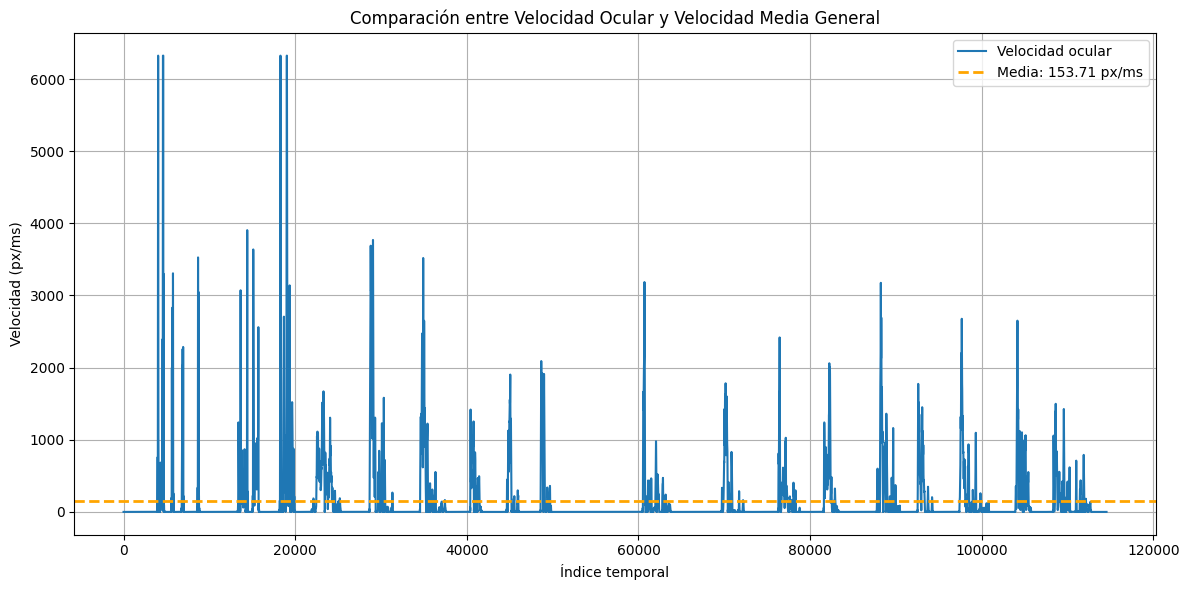

In [51]:
# Calcular velocidad media general
media_vel_general = np.mean(vel)
print(f"Velocidad media general de alineación: {media_vel_general:.2f} px/ms")

# --- Plot comparativo
plt.figure(figsize=(12, 6))

# Señal de velocidad ocular
plt.plot(vel[START:END], label="Velocidad ocular")

# Línea de velocidad media
plt.axhline(media_vel_general, color="orange", linestyle="--", linewidth=2,
            label=f"Media: {media_vel_general:.2f} px/ms")

# Etiquetas y formato
plt.title("Comparación entre Velocidad Ocular y Velocidad Media General")
plt.xlabel("Índice temporal")
plt.ylabel("Velocidad (px/ms)")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [52]:
rellenado

,timestamp,stimuli_x,stimuli_y,stimuli_color,eyes_x,eyes_y,key
0,1755070076908,0,0,16777215,0,0,0
1,1755070076909,0,0,16777215,0,0,0
2,1755070076910,0,0,16777215,0,0,0
3,1755070076911,0,0,16777215,0,0,0
4,1755070076912,0,0,16777215,0,0,0
...,...,...,...,...,...,...,...
114542,1755070191450,221,217,65280,213,228,0
114543,1755070191451,221,217,65280,213,228,0
114544,1755070191452,221,217,65280,213,228,0
114545,1755070191453,221,217,65280,213,228,0


## Velocidad media al exceder el umbral 

Velocidad media en los segmentos en los que se ha excedido el umbral de velocidad (threshold = 1000).  
Para mejor compresión, la gráfica se representa desde el umbral, ignorando los valores por debajo de él

=== DIAGNÓSTICO ===
[Norm] scale: 8.476e+06 (mediana positiva original: 1.180e-07)
[Cap]  P99.5 sobre señal normalizada -> cap = 25105947522.720158
[Thr]  Global P99.0 positivos capados -> THRESHOLD_GLOBAL = 18782625200.171909
Rango velN antes:   min=3.655e-121, max=3.836e+11
Rango velN después: min=3.655e-121, max=2.511e+10
Onsets: 15 | Latencias (adaptativo): 4/15 (perdidos=11)
Latencia media: 869.5 ms | SD: 53.4 ms


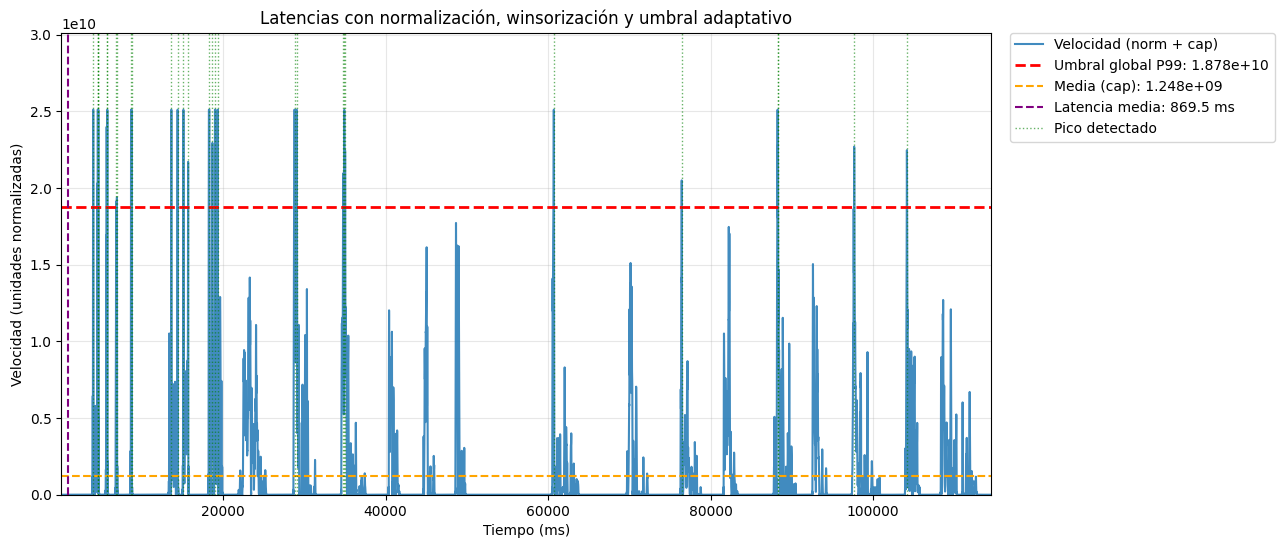

In [53]:
# ============================================
# Latencias robustas con normalización + cap + umbral adaptativo
# ============================================
from scipy.signal import find_peaks
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ========= Parámetros ajustables =========
START = 100
END   = rellenado.shape[0]          # se recorta seguro más abajo

# Filtro de latencia
MIN_DURATION_MS = 10                # ms que debe mantenerse por encima del umbral
MAX_LATENCY_MS  = 1000              # ventana máxima para buscar respuesta

# Normalización + cap (winsorización por percentil)
P_CAP = 99.5                        # percentil para recortar picos (después de normalizar)
P_THR_GLOBAL = 99.0                 # percentil para umbral global, sobre positivos capados

# Umbral adaptativo local
LOCAL_PRE_MS   = 100                # ventana antes del onset para baseline local
LOCAL_POST_MS  = 600                # ventana después del onset para estimar dinámica
LOCAL_P_HI     = 90.0               # percentil alto local para "entrar"
HYST_RATIO     = 0.7                # histéresis: umbral bajo = HYST_RATIO * umbral alto
TOL_GAP_SAMPLES = 2                 # tolera hasta 2 muestras por debajo dentro del bloque

# ========= 0) Señal base en float64 =========
eyes_x = rellenado["eyes_x"].values.astype(np.float64)
eyes_y = rellenado["eyes_y"].values.astype(np.float64)

dis = distance(eyes_x, eyes_y)[1:-1].astype(np.float64)
vel = np.abs(differentiate(dis)).astype(np.float64)
vel = np.abs(denoise_35(vel)).astype(np.float64)  # por si devuelve int o cuantiza

# Seguridad en índices
END = min(END, len(vel))
START = max(0, min(START, END-1))

# ========= 1) Normalización automática de escala =========
xp = vel[vel > 0]
if xp.size > 0:
    med_pos = float(np.median(xp))
    scale = 1.0 if med_pos <= 0 else 1.0 / med_pos
else:
    med_pos = 0.0
    scale = 1.0
velN = vel * scale

# ========= 2) Winsorización (cap superior por percentil) =========
def winsorize_upper(x, p_hi=99.5):
    x = np.asarray(x, dtype=np.float64)
    pos = x[x > 0]
    cap = float(np.percentile(pos, p_hi)) if pos.size else 0.0
    return np.minimum(x, cap), cap

vel_cap, cap_val = winsorize_upper(velN, p_hi=P_CAP)

# ========= 3) Umbral global sobre positivos capados =========
pos_cap = vel_cap[vel_cap > 0]
if pos_cap.size:
    THRESHOLD_GLOBAL = float(np.percentile(pos_cap, P_THR_GLOBAL))
else:
    THRESHOLD_GLOBAL = 0.0

media_vel_general = float(np.mean(vel_cap))

# ========= 4) Picos y onsets (usar SIEMPRE vel_cap) =========
peaks, _ = find_peaks(vel_cap, height=THRESHOLD_GLOBAL)

stim_x = rellenado["stimuli_x"].values
event_onsets = np.where(np.diff(stim_x) != 0)[0] + 1

# ========= 5) Tiempo y parámetros de ventana =========
fs = 1000.0
dt_ms = 1000.0 / fs
tiempo = np.arange(len(vel_cap)) * dt_ms

min_samples = int(round(MIN_DURATION_MS / dt_ms))
max_samples = int(round(MAX_LATENCY_MS / dt_ms))
pre_samp  = int(round(LOCAL_PRE_MS / dt_ms))
post_samp = int(round(LOCAL_POST_MS / dt_ms))

# ========= 6) Latencias con umbral adaptativo por onset + histéresis =========
latencias_ms = []
missed_debug = 0

glob_pos = pos_cap  # alias para claridad

for onset in event_onsets:
    # Ventana local alrededor del onset
    a = max(0, onset - pre_samp)
    b = min(len(vel_cap), onset + post_samp)
    seg = vel_cap[a:b]
    seg_pos = seg[seg > 0]

    # Umbral alto/bajo local
    if seg_pos.size == 0:
        thr_hi = THRESHOLD_GLOBAL
        thr_lo = HYST_RATIO * thr_hi
    else:
        thr_hi = float(np.percentile(seg_pos, LOCAL_P_HI))
        if glob_pos.size:
            floor_thr = float(np.percentile(glob_pos, 80.0))
            thr_hi = max(thr_hi, 0.9 * floor_thr)  # suelo suave
        thr_lo = HYST_RATIO * thr_hi

    # Búsqueda con histéresis y tolerancia a micro-cortes
    found = None
    if onset < len(vel_cap) - min_samples:
        j_lim = min(len(vel_cap) - min_samples, onset + max_samples)

        # 1) Esperar cruce de thr_hi
        i = onset
        while i < j_lim and vel_cap[i] < thr_hi:
            i += 1

        # 2) Comprobar mantenimiento por encima de thr_lo con tolerancia
        if i < j_lim:
            run = 0
            gaps = 0
            k = i
            while k < j_lim and run < min_samples:
                if vel_cap[k] >= thr_lo:
                    run += 1
                else:
                    gaps += 1
                    if gaps <= TOL_GAP_SAMPLES:
                        run += 1     # tolera agujeros pequeños
                    else:
                        run = 0      # reinicia bloque
                        gaps = 0
                k += 1

            if run >= min_samples:
                found = i  # latencia = primer cruce del umbral alto

    if found is not None:
        latencias_ms.append((found - onset) * dt_ms)
    else:
        missed_debug += 1

lat_mean_ms = float(np.mean(latencias_ms)) if latencias_ms else None

# ========= 7) Diagnóstico por consola =========
print("=== DIAGNÓSTICO ===")
print(f"[Norm] scale: {scale:.3e} (mediana positiva original: {med_pos:.3e})")
print(f"[Cap]  P{P_CAP} sobre señal normalizada -> cap = {cap_val:.6f}")
print(f"[Thr]  Global P{P_THR_GLOBAL} positivos capados -> THRESHOLD_GLOBAL = {THRESHOLD_GLOBAL:.6f}")
print(f"Rango velN antes:   min={velN.min():.3e}, max={velN.max():.3e}")
print(f"Rango velN después: min={vel_cap.min():.3e}, max={vel_cap.max():.3e}")
print(f"Onsets: {len(event_onsets)} | Latencias (adaptativo): {len(latencias_ms)}/{len(event_onsets)} (perdidos={missed_debug})")
if latencias_ms:
    print(f"Latencia media: {lat_mean_ms:.1f} ms | SD: {np.std(latencias_ms, ddof=1):.1f} ms")

# ========= 8) Plot robusto (ax.* y rcParams reset) =========
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['figure.figsize'] = (12, 6)

fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# Señal capada
ax.plot(tiempo[START:END], vel_cap[START:END], label="Velocidad (norm + cap)", alpha=0.85)

# Líneas de referencia (globales)
ax.axhline(THRESHOLD_GLOBAL, color="r", linestyle="--", linewidth=2,
           label=f"Umbral global P{int(P_THR_GLOBAL)}: {THRESHOLD_GLOBAL:.3e}")
ax.axhline(media_vel_general, color="orange", linestyle="--",
           label=f"Media (cap): {media_vel_general:.3e}")

# Latencia media (si existe)
if lat_mean_ms is not None:
    ax.axvline(lat_mean_ms, color="purple", linestyle="--",
               label=f"Latencia media: {lat_mean_ms:.1f} ms")

# Picos (diagnóstico visual)
labeled = False
for p in peaks:
    if START <= p < END:
        ax.axvline(tiempo[p], color='g', linestyle=':', alpha=0.6, linewidth=1,
                   label="Pico detectado" if not labeled else "")
        labeled = True

# Límites de ejes
ax.set_xlim(tiempo[START], tiempo[END-1])
ymax = float(np.nanmax(vel_cap[START:END])) if END-START > 1 else float(vel_cap[START])
ax.set_ylim(0, max(1.2 * ymax, 1.0))

# Título y decoración
ax.set_title("Latencias con normalización, winsorización y umbral adaptativo")
ax.set_xlabel("Tiempo (ms)")
ax.set_ylabel("Velocidad (unidades normalizadas)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.grid(True, alpha=0.3)

plt.show()


La desviación típica es muy alta porque la distribución está muy dispersa y sesgada. La mediana (≈ 1454) y el rango intercuartílico (≈ 1120–1987) muestran que la mayoría de los valores están en torno a ese intervalo. Sin embargo, la media (≈ 2076) resulta bastante mayor debido a la presencia de valores extremos mucho más altos, que inflan tanto la media como la desviación típica (≈ 2287). Esto indica que, aunque la mayor parte de las velocidades típicas tras el umbral se concentran en torno a 1.5 k, existen ráfagas puntuales de picos mucho más grandes que generan gran variabilidad.

# CODIGO PARA VELOCIDAD > UMBRAL (FINAL)

INFO: Artefacto extremo detectado y pre-corregido.

[Lag] Lag estimado: 1285.0 ms. Corrección aplicada: True (1285.0 ms)


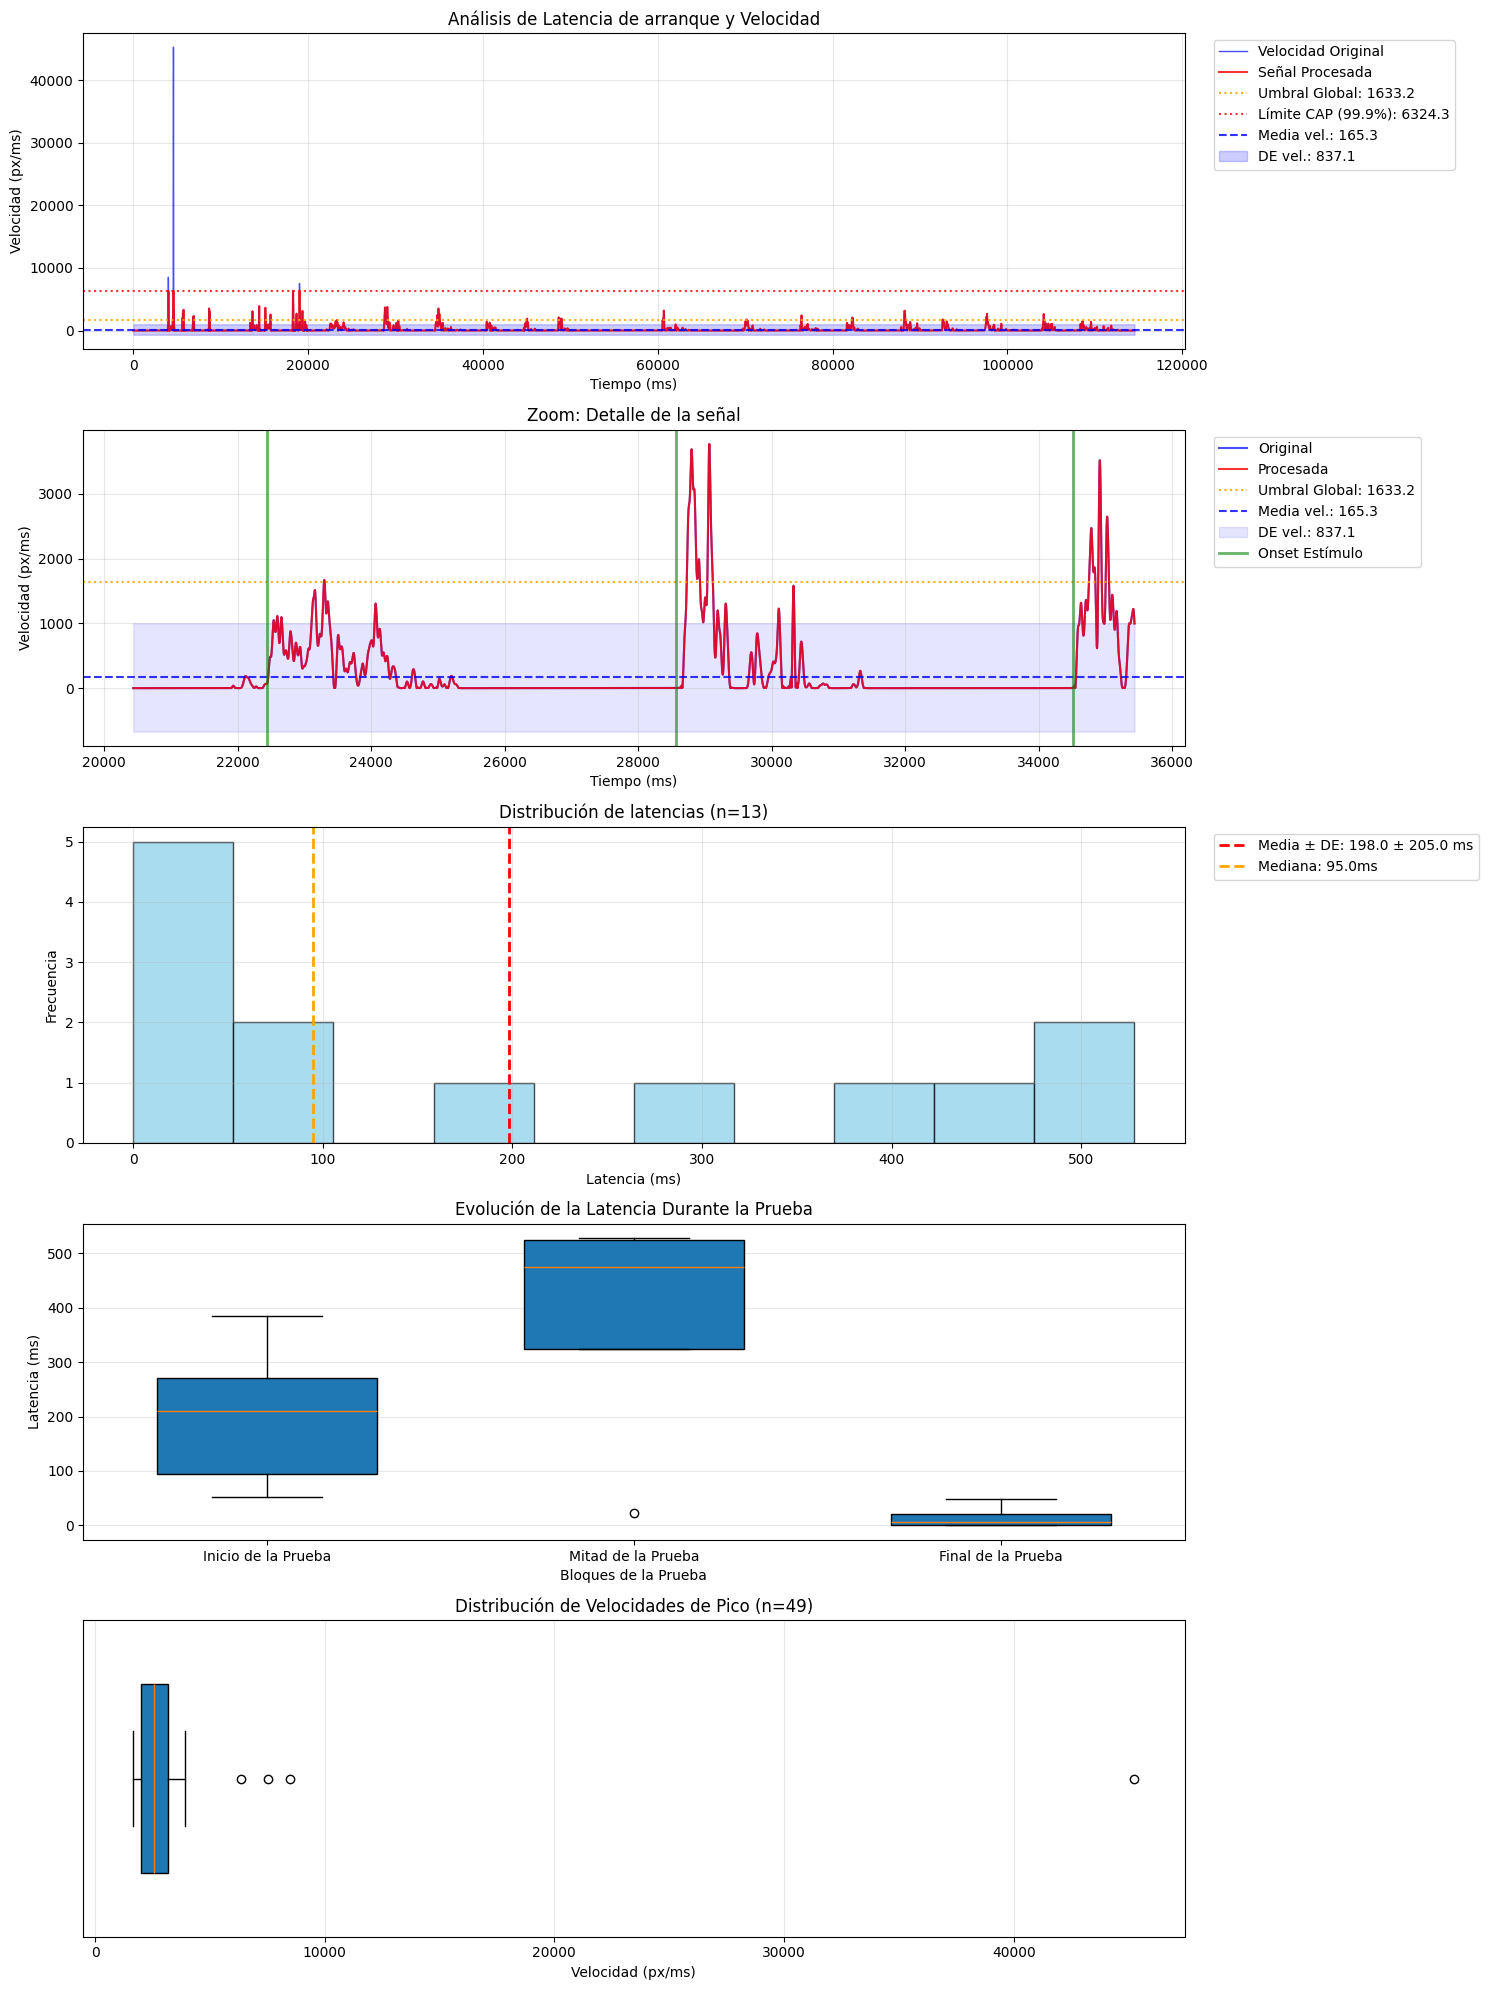

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
from scipy.signal import find_peaks

# ================== Parámetros Fusionados ==================
START = 0
END   = rellenado.shape[0]

# --- Parámetros de Detección Avanzada ---
MIN_DURATION_MS = 10      # ms que debe mantenerse por encima del umbral
MAX_LATENCY_MS  = 1000    # Ventana máxima para buscar respuesta
P_CAP = 99.9              # Percentil para recortar picos (100 = sin cap)
P_THR_GLOBAL = 98.0       # Percentil para umbral global
LOCAL_PRE_MS   = 100      # Ventana antes del onset para baseline local
LOCAL_POST_MS  = 600      # Ventana después del onset para estimar dinámica
LOCAL_P_HI     = 90.0     # Percentil alto local
HYST_RATIO     = 0.7      # Histéresis: umbral bajo = HYST_RATIO * umbral alto
TOL_GAP_SAMPLES = 2       # Tolera hasta 2 muestras por debajo dentro del bloque

# --- Parámetros de Lag ---
AUTO_LAG = True
LAG_APPLY_MIN_MS = 60      # Umbral mínimo para aplicar corrección de lag (ej. 60ms)
LAG_SEARCH_MS = 2000
SMOOTH_MS     = 50

# ================== 0) Señal y Conversión de Tiempo ==================
fs = 1000.0
dt_ms = 1000.0 / fs

eyes_x = rellenado["eyes_x"].values.astype(np.float64)
eyes_y = rellenado["eyes_y"].values.astype(np.float64)

dis = distance(eyes_x, eyes_y)[1:-1].astype(np.float64)
vel = np.abs(differentiate(dis)).astype(np.float64)
vel = np.abs(denoise_35(vel)).astype(np.float64)
vel_original = vel.copy()

END = min(END, len(vel))

# ================== 1) Normalización y Capping (Winsorización) ==================
p999_pre = np.percentile(vel[vel > 0], 99.9) if np.any(vel > 0) else 0.0
spike_threshold = p999_pre * 3.0
if np.any(vel > spike_threshold):
    print(f"INFO: Artefacto extremo detectado y pre-corregido.")
    vel_pre_cleaned = np.clip(vel, None, p999_pre)
else:
    vel_pre_cleaned = vel.copy()

xp = vel_pre_cleaned[vel_pre_cleaned > 0]
med_pos = float(np.median(xp)) if xp.size > 0 else 1.0
scale = 1.0 / med_pos if med_pos > 0 else 1.0
vel_norm = vel * scale

cap_val = float(np.percentile(vel_norm[vel_norm > 0], P_CAP)) if np.any(vel_norm > 0) else 0.0
vel_cap = np.minimum(vel_norm, cap_val)

pos_cap = vel_cap[vel_cap > 0]
THRESHOLD_GLOBAL = float(np.percentile(pos_cap, P_THR_GLOBAL)) if pos_cap.size else 0.0
thr_global_denorm = THRESHOLD_GLOBAL / scale

# ================== 2) Onsets y Corrección de Lag ==================
stim_x = rellenado["stimuli_x"].values
event_onsets = np.where(np.diff(stim_x) != 0)[0] + 1
event_onsets = event_onsets[(event_onsets >= 0) & (event_onsets < len(vel))]

# --- INICIO DEL BLOQUE DE CORRECCIÓN DE LAG REINTRODUCIDO ---
def moving_rms(x, w):
    if len(x) < w: return x.copy()
    sw = sliding_window_view(x, w); rms = np.sqrt((sw**2).mean(axis=-1))
    pad_left = w//2; pad_right = len(x) - len(rms) - pad_left
    return np.pad(rms, (pad_left, pad_right), mode='edge')

win = max(1, int(round(SMOOTH_MS / dt_ms)))
env = moving_rms(vel_original, win)
imp = np.zeros(len(vel)); imp[event_onsets] = 1.0
imp_n = (imp - imp.mean()) / (imp.std() + 1e-12); env_n = (env - env.mean()) / (env.std() + 1e-12)
xc = np.correlate(env_n, imp_n, mode='full'); lags = np.arange(-len(vel)+1, len(vel))
max_lag_samp = int(round(LAG_SEARCH_MS / dt_ms))
mask = (lags >= -max_lag_samp) & (lags <= max_lag_samp)
lags_short = lags[mask]; xc_short = xc[mask]
best_lag_samp = int(lags_short[np.argmax(xc_short)])
best_lag_ms = best_lag_samp * dt_ms

# Decisión de corrección
APPLY_LAG = AUTO_LAG and (best_lag_ms >= LAG_APPLY_MIN_MS)
lag_used_samp = best_lag_samp if APPLY_LAG else 0

# Aplicar la corrección a los onsets
event_onsets_corr = event_onsets + lag_used_samp
event_onsets_corr = event_onsets_corr[(event_onsets_corr >= 0) & (event_onsets_corr < len(vel))]

print(f"\n[Lag] Lag estimado: {best_lag_ms:.1f} ms. Corrección aplicada: {APPLY_LAG} ({lag_used_samp * dt_ms:.1f} ms)")
# --- FIN DEL BLOQUE ---

min_samples = int(round(MIN_DURATION_MS / dt_ms))
max_samples = int(round(MAX_LATENCY_MS / dt_ms))
pre_samp    = int(round(LOCAL_PRE_MS / dt_ms))
post_samp   = int(round(LOCAL_POST_MS / dt_ms))

# ================== 3) Detección de Latencia Robusta (con Histéresis) ==================
latencias_ms = []
for onset in event_onsets_corr:
    a = max(0, onset - pre_samp); b = min(len(vel_cap), onset + post_samp)
    seg = vel_cap[a:b]; seg_pos = seg[seg > 0]
    if seg_pos.size < 10: thr_hi = THRESHOLD_GLOBAL
    else: thr_hi = float(np.percentile(seg_pos, LOCAL_P_HI))
    thr_lo = HYST_RATIO * thr_hi
    found = None
    if onset < len(vel_cap) - min_samples:
        j_lim = min(len(vel_cap), onset + max_samples); i = onset
        while i < j_lim and vel_cap[i] < thr_hi: i += 1
        if i < j_lim:
            run = 0; gaps = 0; k = i
            while k < len(vel_cap) and run < min_samples and k < onset + max_samples:
                if vel_cap[k] >= thr_lo: run += 1; gaps = 0
                else:
                    gaps += 1
                    if gaps <= TOL_GAP_SAMPLES: run += 1
                    else:
                        run = 0; gaps = 0; i = k + 1
                        while i < j_lim and vel_cap[i] < thr_hi: i += 1
                        k = i -1
                k += 1
            if run >= min_samples: found = i
    if found is not None: latencias_ms.append((found - onset) * dt_ms)

# ================== 4) Resultados y Estadísticas ==================
lat_mean_ms = float(np.mean(latencias_ms)) if latencias_ms else None
lat_std_ms = float(np.std(latencias_ms, ddof=1)) if latencias_ms else None
picos_significativos, _ = find_peaks(vel_original, height=thr_global_denorm)
velocidades_picos = vel_original[picos_significativos]



# ================== 5) Gráfico Integrado con 5 Subplots ==================
t_ms = np.arange(len(vel)) * dt_ms
vel_cap_denorm = vel_cap / scale

plt.figure(figsize=(15, 20))

# --- Subplot 1: Señal completa ---
ax1 = plt.subplot(5, 1, 1)
ax1.plot(t_ms[START:END], vel_original[START:END], 'b-', alpha=0.7, linewidth=1, label="Velocidad Original")
ax1.plot(t_ms[START:END], vel_cap_denorm[START:END], 'r-', alpha=0.8, linewidth=1.5, label="Señal Procesada")
ax1.axhline(thr_global_denorm, color='orange', linestyle=':', alpha=0.9, label=f"Umbral Global: {thr_global_denorm:.1f}")
if P_CAP < 100:
    cap_denorm = cap_val / scale
    ax1.axhline(cap_denorm, color='red', linestyle=':', alpha=0.8, label=f"Límite CAP ({P_CAP}%): {cap_denorm:.1f}")
ax1.axhline(media_vel_original, color="blue", linestyle="--", alpha=0.8, label=f"Media vel.: {media_vel_original:.1f}")
ax1.fill_between(t_ms[START:END], media_vel_original - std_vel_original, media_vel_original + std_vel_original, 
                 color='blue', alpha=0.2, label=f"DE vel.: {std_vel_original:.1f}")
title_lat = f"Latencia media: {lat_mean_ms:.1f} $\\pm$ {lat_std_ms:.1f} ms" if lat_mean_ms and lat_std_ms else "Latencia no calculada"
ax1.set_title(f"Análisis de Latencia de arranque y Velocidad")
ax1.set_ylabel("Velocidad (px/ms)")
ax1.set_xlabel("Tiempo (ms)") # <-- EJE AÑADIDO
handles, labels = ax1.get_legend_handles_labels(); by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc="upper left")
ax1.grid(True, alpha=0.3)


# --- Subplot 2: Zoom ---
ax2 = plt.subplot(5, 1, 2)
if len(event_onsets_corr) > 0:
    primer_onset = event_onsets_corr[event_onsets_corr >= START][0] if np.any(event_onsets_corr >= START) else event_onsets_corr[0]
    zoom_start = max(START, primer_onset - int(2000/dt_ms))
    zoom_end = min(END, zoom_start + int(15000/dt_ms))
else:
    zoom_start = max(START, int(5000/dt_ms)); zoom_end = min(END, zoom_start + int(10000/dt_ms))

ax2.plot(t_ms[zoom_start:zoom_end], vel_original[zoom_start:zoom_end], 'b-', alpha=0.7, label="Original")
ax2.plot(t_ms[zoom_start:zoom_end], vel_cap_denorm[zoom_start:zoom_end], 'r-', alpha=0.8, label="Procesada")
ax2.axhline(thr_global_denorm, color='orange', linestyle=':', alpha=0.9, label=f"Umbral Global: {thr_global_denorm:.1f}")
ax2.axhline(media_vel_original, color="blue", linestyle="--", alpha=0.8, label=f"Media vel.: {media_vel_original:.1f}")
ax2.fill_between(t_ms[zoom_start:zoom_end], media_vel_original - std_vel_original, media_vel_original + std_vel_original, 
                 color='blue', alpha=0.1, label=f"DE vel.: {std_vel_original:.1f}")
label_onset_2 = "Onset Estímulo"
for onset in event_onsets_corr:
    if zoom_start <= onset < zoom_end:
        ax2.axvline(onset * dt_ms, color="green", alpha=0.6, linewidth=2, label=label_onset_2)
        label_onset_2 = None
ax2.set_title("Zoom: Detalle de la señal")
ax2.set_ylabel("Velocidad (px/ms)")
ax2.set_xlabel("Tiempo (ms)") # <-- EJE AÑADIDO
handles, labels = ax2.get_legend_handles_labels(); by_label = dict(zip(labels, handles))
ax2.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc="upper left")
ax2.grid(True, alpha=0.3)


# --- Subplot 3: Histograma de latencias ---

ax3 = plt.subplot(5, 1, 3)
if latencias_ms:
    ax3.hist(latencias_ms, bins=min(20, max(10, len(latencias_ms)//2)), alpha=0.7, edgecolor='black', color='skyblue')

    if lat_mean_ms is not None and lat_std_ms is not None:
        # 1. Crear la etiqueta combinada que quieres
        label_media_std = f"Media ± DE: {lat_mean_ms:.1f} ± {lat_std_ms:.1f} ms"
        
       
        # 2. Dibujar la línea de la media CON la etiqueta combinada
        ax3.axvline(lat_mean_ms, color="red", linestyle="--", linewidth=2, label=label_media_std)

    # La línea de la mediana se mantiene como una entrada separada en la leyenda
    ax3.axvline(np.median(latencias_ms), color="orange", linestyle="--", linewidth=2, label=f"Mediana: {np.median(latencias_ms):.1f}ms")
    
    ax3.set_xlabel("Latencia (ms)")
    ax3.set_ylabel("Frecuencia")
    ax3.set_title(f"Distribución de latencias (n={len(latencias_ms)})")
    ax3.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax3.grid(True, alpha=0.3)

# --- Subplot 4: Boxplot de Evolución de Latencia ---
ax4 = plt.subplot(5, 1, 4)
if latencias_ms and len(latencias_ms) >= 3:
    bloques = np.array_split(np.array(latencias_ms), 3)
    ax4.boxplot(bloques, patch_artist=True, widths=0.6)
    ax4.set_xticklabels(['Inicio de la Prueba', 'Mitad de la Prueba', 'Final de la Prueba'])
    ax4.set_title("Evolución de la Latencia Durante la Prueba")
    ax4.set_ylabel("Latencia (ms)")
    ax4.set_xlabel("Bloques de la Prueba") # <-- EJE AÑADIDO
    ax4.grid(True, axis='y', alpha=0.3)
else:
    ax4.text(0.5, 0.5, "No hay suficientes latencias para generar el gráfico de evolución.", ha='center', va='center', transform=ax4.transAxes)

# --- Subplot 5: Boxplot de Velocidades de Pico ---
ax5 = plt.subplot(5, 1, 5)
if velocidades_picos.size > 0:
    ax5.boxplot(velocidades_picos, vert=False, patch_artist=True, widths=0.6)
    ax5.set_title(f"Distribución de Velocidades de Pico (n={len(velocidades_picos)})")
    ax5.set_xlabel("Velocidad (px/ms)")
    ax5.set_yticks([])
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, "No se encontraron picos significativos para el boxplot.", ha='center', va='center', transform=ax5.transAxes)

plt.tight_layout()
plt.show()

INFO: Artefacto extremo detectado y pre-corregido.

[Lag] Lag estimado: 1285.0 ms. Corrección aplicada: True (1285.0 ms)


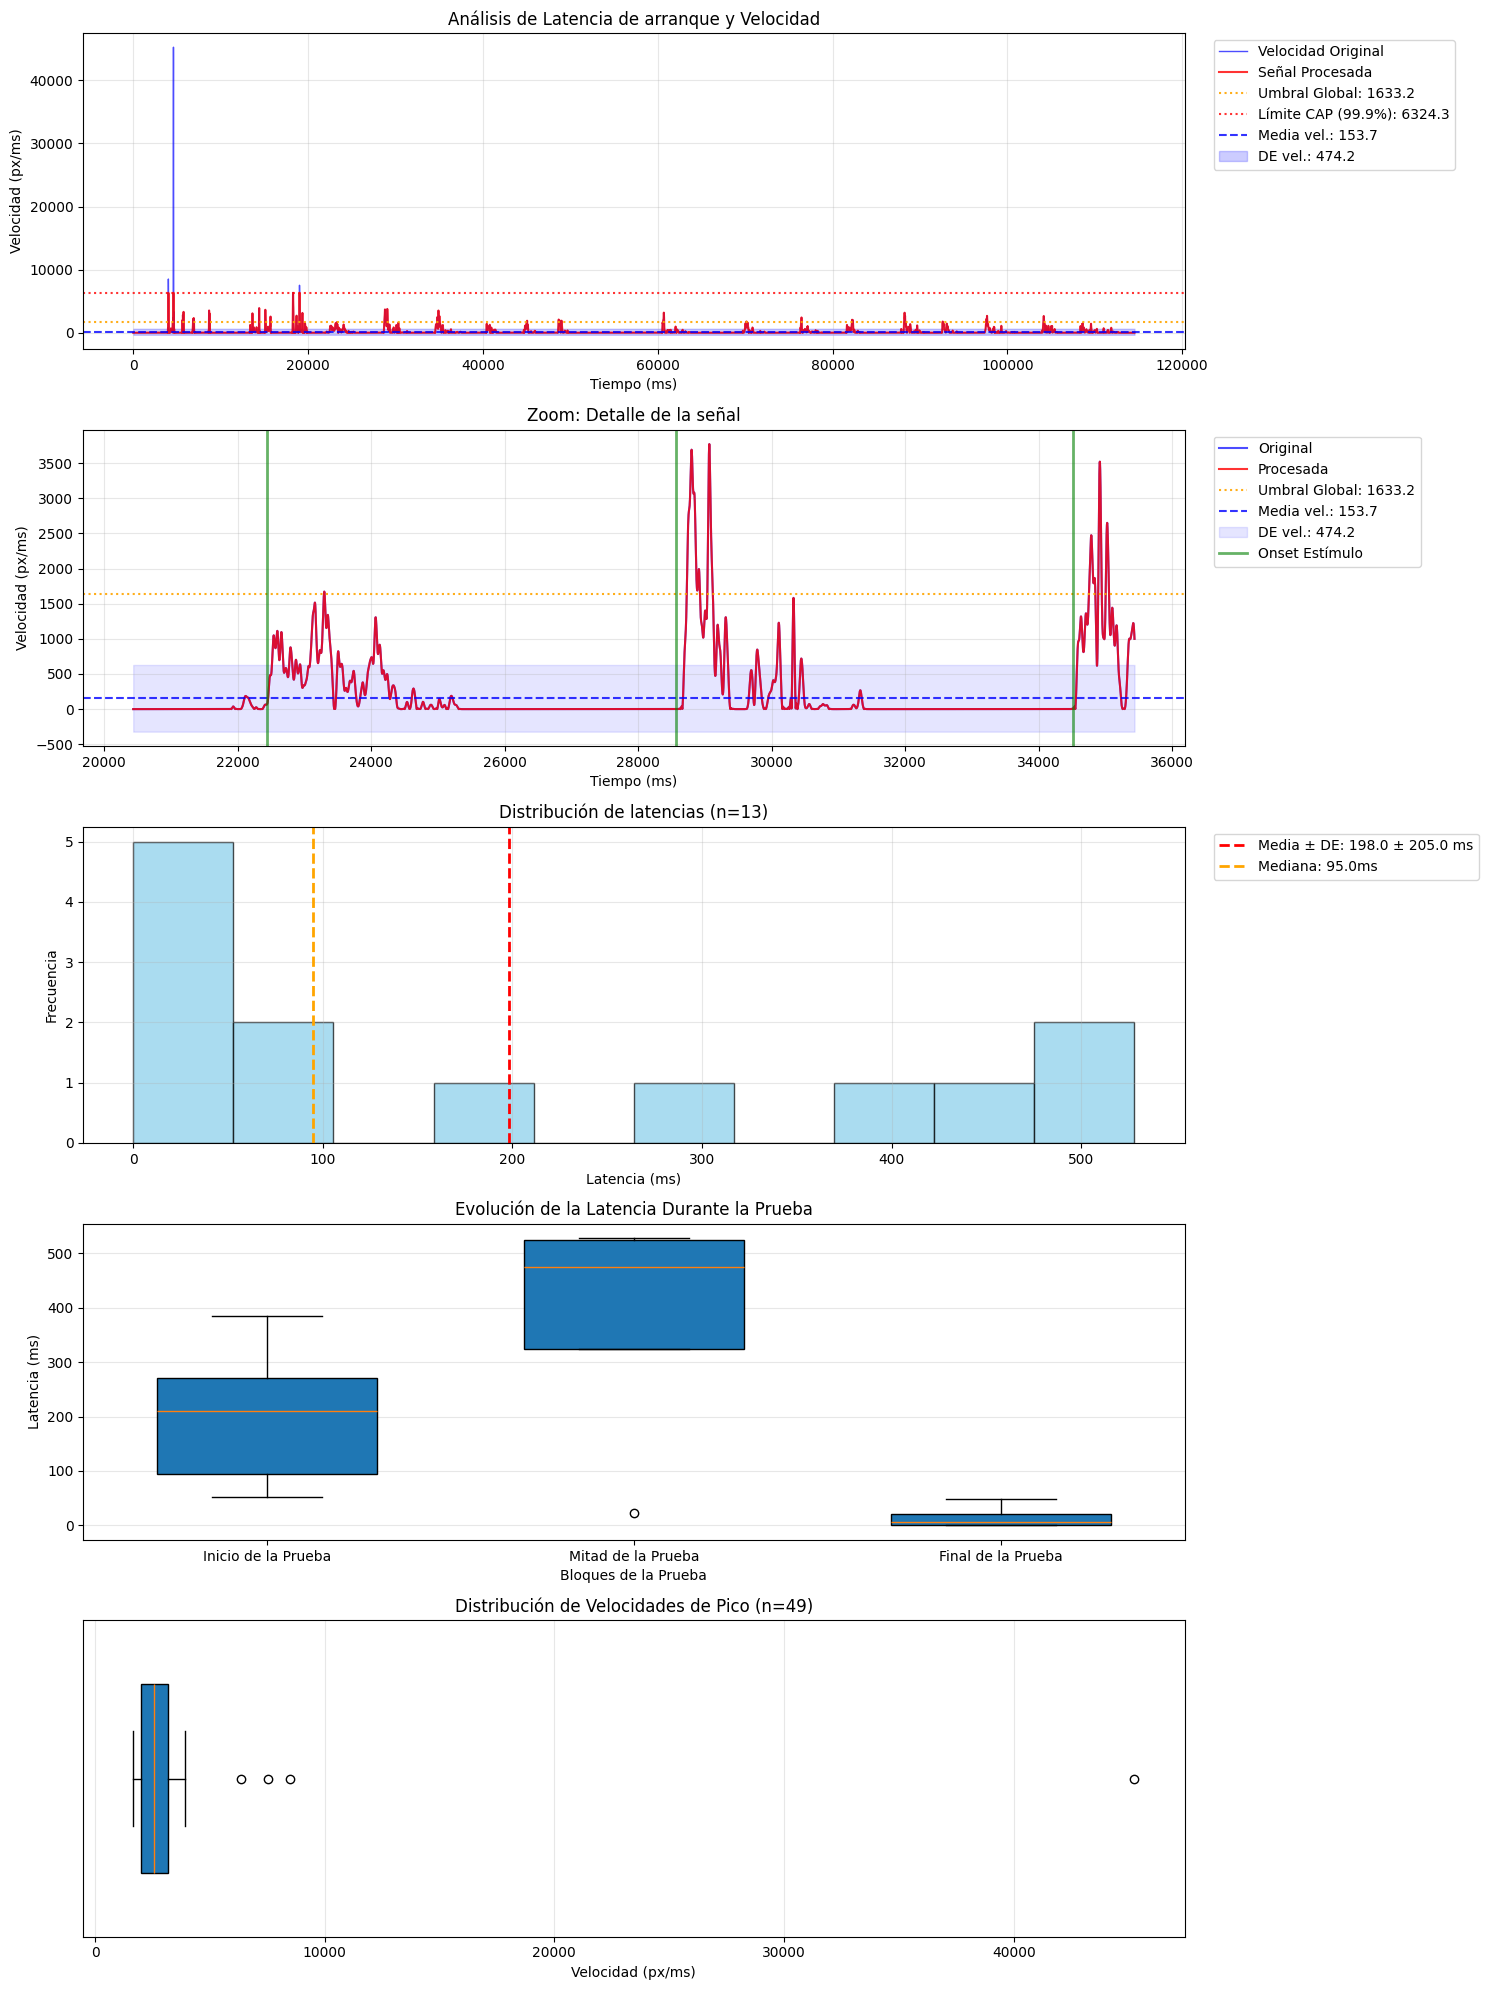

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
from scipy.signal import find_peaks

# ================== Parámetros Fusionados ==================
START = 0
END   = rellenado.shape[0]

# --- Parámetros de Detección Avanzada ---
MIN_DURATION_MS = 10      # ms que debe mantenerse por encima del umbral
MAX_LATENCY_MS  = 1000    # Ventana máxima para buscar respuesta
P_CAP = 99.9              # Percentil para recortar picos (100 = sin cap)
P_THR_GLOBAL = 98.0       # Percentil para umbral global
LOCAL_PRE_MS   = 100      # Ventana antes del onset para baseline local
LOCAL_POST_MS  = 600      # Ventana después del onset para estimar dinámica
LOCAL_P_HI     = 90.0     # Percentil alto local
HYST_RATIO     = 0.7      # Histéresis: umbral bajo = HYST_RATIO * umbral alto
TOL_GAP_SAMPLES = 2       # Tolera hasta 2 muestras por debajo dentro del bloque

# --- Parámetros de Lag ---
AUTO_LAG = True
LAG_APPLY_MIN_MS = 60      # Umbral mínimo para aplicar corrección de lag (ej. 60ms)
LAG_SEARCH_MS = 2000
SMOOTH_MS      = 50

# ================== 0) Señal y Conversión de Tiempo ==================
fs = 1000.0
dt_ms = 1000.0 / fs

eyes_x = rellenado["eyes_x"].values.astype(np.float64)
eyes_y = rellenado["eyes_y"].values.astype(np.float64)

# Las funciones `distance`, `differentiate` y `denoise_35` deben estar definidas
# antes de usarlas. Aquí asumo que están definidas en tu entorno de trabajo.
# Si no, debes incluirlas aquí.
# def distance(x, y):
#     return np.hypot(np.diff(x), np.diff(y))
# def differentiate(x):
#     return np.diff(x) * fs / 1000.0
# def denoise_35(x):
#     return np.convolve(x, np.ones(35)/35, mode='same')

dis = distance(eyes_x, eyes_y)[1:-1].astype(np.float64)
vel = np.abs(differentiate(dis)).astype(np.float64)
vel = np.abs(denoise_35(vel)).astype(np.float64)
vel_original = vel.copy()

END = min(END, len(vel))

# ================== 1) Normalización y Capping (Winsorización) ==================
p999_pre = np.percentile(vel[vel > 0], 99.9) if np.any(vel > 0) else 0.0
spike_threshold = p999_pre * 3.0
if np.any(vel > spike_threshold):
    print(f"INFO: Artefacto extremo detectado y pre-corregido.")
    vel_pre_cleaned = np.clip(vel, None, p999_pre)
else:
    vel_pre_cleaned = vel.copy()

xp = vel_pre_cleaned[vel_pre_cleaned > 0]
med_pos = float(np.median(xp)) if xp.size > 0 else 1.0
scale = 1.0 / med_pos if med_pos > 0 else 1.0
vel_norm = vel * scale

cap_val = float(np.percentile(vel_norm[vel_norm > 0], P_CAP)) if np.any(vel_norm > 0) else 0.0
vel_cap = np.minimum(vel_norm, cap_val)

pos_cap = vel_cap[vel_cap > 0]
THRESHOLD_GLOBAL = float(np.percentile(pos_cap, P_THR_GLOBAL)) if pos_cap.size else 0.0
thr_global_denorm = THRESHOLD_GLOBAL / scale

# =====> CAMBIO CRUCIAL: CALCULAR ESTADÍSTICAS SOBRE LA SEÑAL PROCESADA
vel_cap_denorm = vel_cap / scale
media_vel_procesada = float(np.mean(vel_cap_denorm))
std_vel_procesada = float(np.std(vel_cap_denorm))

# ================== 2) Onsets y Corrección de Lag ==================
stim_x = rellenado["stimuli_x"].values
event_onsets = np.where(np.diff(stim_x) != 0)[0] + 1
event_onsets = event_onsets[(event_onsets >= 0) & (event_onsets < len(vel))]

# --- INICIO DEL BLOQUE DE CORRECCIÓN DE LAG REINTRODUCIDO ---
def moving_rms(x, w):
    if len(x) < w: return x.copy()
    sw = sliding_window_view(x, w); rms = np.sqrt((sw**2).mean(axis=-1))
    pad_left = w//2; pad_right = len(x) - len(rms) - pad_left
    return np.pad(rms, (pad_left, pad_right), mode='edge')

win = max(1, int(round(SMOOTH_MS / dt_ms)))
env = moving_rms(vel_original, win)
imp = np.zeros(len(vel)); imp[event_onsets] = 1.0
imp_n = (imp - imp.mean()) / (imp.std() + 1e-12); env_n = (env - env.mean()) / (env.std() + 1e-12)
xc = np.correlate(env_n, imp_n, mode='full'); lags = np.arange(-len(vel)+1, len(vel))
max_lag_samp = int(round(LAG_SEARCH_MS / dt_ms))
mask = (lags >= -max_lag_samp) & (lags <= max_lag_samp)
lags_short = lags[mask]; xc_short = xc[mask]
best_lag_samp = int(lags_short[np.argmax(xc_short)])
best_lag_ms = best_lag_samp * dt_ms

# Decisión de corrección
APPLY_LAG = AUTO_LAG and (best_lag_ms >= LAG_APPLY_MIN_MS)
lag_used_samp = best_lag_samp if APPLY_LAG else 0

# Aplicar la corrección a los onsets
event_onsets_corr = event_onsets + lag_used_samp
event_onsets_corr = event_onsets_corr[(event_onsets_corr >= 0) & (event_onsets_corr < len(vel))]

print(f"\n[Lag] Lag estimado: {best_lag_ms:.1f} ms. Corrección aplicada: {APPLY_LAG} ({lag_used_samp * dt_ms:.1f} ms)")
# --- FIN DEL BLOQUE ---

min_samples = int(round(MIN_DURATION_MS / dt_ms))
max_samples = int(round(MAX_LATENCY_MS / dt_ms))
pre_samp    = int(round(LOCAL_PRE_MS / dt_ms))
post_samp   = int(round(LOCAL_POST_MS / dt_ms))

# ================== 3) Detección de Latencia Robusta (con Histéresis) ==================
latencias_ms = []
for onset in event_onsets_corr:
    a = max(0, onset - pre_samp); b = min(len(vel_cap), onset + post_samp)
    seg = vel_cap[a:b]; seg_pos = seg[seg > 0]
    if seg_pos.size < 10: thr_hi = THRESHOLD_GLOBAL
    else: thr_hi = float(np.percentile(seg_pos, LOCAL_P_HI))
    thr_lo = HYST_RATIO * thr_hi
    found = None
    if onset < len(vel_cap) - min_samples:
        j_lim = min(len(vel_cap), onset + max_samples); i = onset
        while i < j_lim and vel_cap[i] < thr_hi: i += 1
        if i < j_lim:
            run = 0; gaps = 0; k = i
            while k < len(vel_cap) and run < min_samples and k < onset + max_samples:
                if vel_cap[k] >= thr_lo: run += 1; gaps = 0
                else:
                    gaps += 1
                    if gaps <= TOL_GAP_SAMPLES: run += 1
                    else:
                        run = 0; gaps = 0; i = k + 1
                        while i < j_lim and vel_cap[i] < thr_hi: i += 1
                        k = i -1
                k += 1
            if run >= min_samples: found = i
    if found is not None: latencias_ms.append((found - onset) * dt_ms)

# ================== 4) Resultados y Estadísticas ==================
lat_mean_ms = float(np.mean(latencias_ms)) if latencias_ms else None
lat_std_ms = float(np.std(latencias_ms, ddof=1)) if latencias_ms else None
picos_significativos, _ = find_peaks(vel_original, height=thr_global_denorm)
velocidades_picos = vel_original[picos_significativos]


# ================== 5) Gráfico Integrado con 5 Subplots ==================
t_ms = np.arange(len(vel)) * dt_ms
# La variable vel_cap_denorm se usa para el gráfico,
# pero las estadísticas se calculan sobre la señal limpia.
# El problema es que se usan las variables de la señal original en los gráficos
# a continuación. Lo corregimos.

plt.figure(figsize=(15, 20))

# --- Subplot 1: Señal completa ---
ax1 = plt.subplot(5, 1, 1)
ax1.plot(t_ms[START:END], vel_original[START:END], 'b-', alpha=0.7, linewidth=1, label="Velocidad Original")
ax1.plot(t_ms[START:END], vel_cap_denorm[START:END], 'r-', alpha=0.8, linewidth=1.5, label="Señal Procesada")
ax1.axhline(thr_global_denorm, color='orange', linestyle=':', alpha=0.9, label=f"Umbral Global: {thr_global_denorm:.1f}")
if P_CAP < 100:
    cap_denorm = cap_val / scale
    ax1.axhline(cap_denorm, color='red', linestyle=':', alpha=0.8, label=f"Límite CAP ({P_CAP}%): {cap_denorm:.1f}")
# =====> CAMBIO: Usar variables de la señal procesada para la media y DE
ax1.axhline(media_vel_procesada, color="blue", linestyle="--", alpha=0.8, label=f"Media vel.: {media_vel_procesada:.1f}")
ax1.fill_between(t_ms[START:END], media_vel_procesada - std_vel_procesada, media_vel_procesada + std_vel_procesada,
                 color='blue', alpha=0.2, label=f"DE vel.: {std_vel_procesada:.1f}")
title_lat = f"Latencia media: {lat_mean_ms:.1f} $\\pm$ {lat_std_ms:.1f} ms" if lat_mean_ms and lat_std_ms else "Latencia no calculada"
ax1.set_title(f"Análisis de Latencia de arranque y Velocidad")
ax1.set_ylabel("Velocidad (px/ms)")
ax1.set_xlabel("Tiempo (ms)")
handles, labels = ax1.get_legend_handles_labels(); by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc="upper left")
ax1.grid(True, alpha=0.3)


# --- Subplot 2: Zoom ---
ax2 = plt.subplot(5, 1, 2)
if len(event_onsets_corr) > 0:
    primer_onset = event_onsets_corr[event_onsets_corr >= START][0] if np.any(event_onsets_corr >= START) else event_onsets_corr[0]
    zoom_start = max(START, primer_onset - int(2000/dt_ms))
    zoom_end = min(END, zoom_start + int(15000/dt_ms))
else:
    zoom_start = max(START, int(5000/dt_ms)); zoom_end = min(END, zoom_start + int(10000/dt_ms))

ax2.plot(t_ms[zoom_start:zoom_end], vel_original[zoom_start:zoom_end], 'b-', alpha=0.7, label="Original")
ax2.plot(t_ms[zoom_start:zoom_end], vel_cap_denorm[zoom_start:zoom_end], 'r-', alpha=0.8, label="Procesada")
ax2.axhline(thr_global_denorm, color='orange', linestyle=':', alpha=0.9, label=f"Umbral Global: {thr_global_denorm:.1f}")
# =====> CAMBIO: Usar variables de la señal procesada para la media y DE
ax2.axhline(media_vel_procesada, color="blue", linestyle="--", alpha=0.8, label=f"Media vel.: {media_vel_procesada:.1f}")
ax2.fill_between(t_ms[zoom_start:zoom_end], media_vel_procesada - std_vel_procesada, media_vel_procesada + std_vel_procesada,
                 color='blue', alpha=0.1, label=f"DE vel.: {std_vel_procesada:.1f}")
label_onset_2 = "Onset Estímulo"
for onset in event_onsets_corr:
    if zoom_start <= onset < zoom_end:
        ax2.axvline(onset * dt_ms, color="green", alpha=0.6, linewidth=2, label=label_onset_2)
        label_onset_2 = None
ax2.set_title("Zoom: Detalle de la señal")
ax2.set_ylabel("Velocidad (px/ms)")
ax2.set_xlabel("Tiempo (ms)")
handles, labels = ax2.get_legend_handles_labels(); by_label = dict(zip(labels, handles))
ax2.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc="upper left")
ax2.grid(True, alpha=0.3)


# --- Subplot 3: Histograma de latencias ---
ax3 = plt.subplot(5, 1, 3)
if latencias_ms:
    ax3.hist(latencias_ms, bins=min(20, max(10, len(latencias_ms)//2)), alpha=0.7, edgecolor='black', color='skyblue')
    if lat_mean_ms is not None and lat_std_ms is not None:
        label_media_std = f"Media ± DE: {lat_mean_ms:.1f} ± {lat_std_ms:.1f} ms"
        ax3.axvline(lat_mean_ms, color="red", linestyle="--", linewidth=2, label=label_media_std)
    ax3.axvline(np.median(latencias_ms), color="orange", linestyle="--", linewidth=2, label=f"Mediana: {np.median(latencias_ms):.1f}ms")
    ax3.set_xlabel("Latencia (ms)")
    ax3.set_ylabel("Frecuencia")
    ax3.set_title(f"Distribución de latencias (n={len(latencias_ms)})")
    ax3.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax3.grid(True, alpha=0.3)


# --- Subplot 4: Boxplot de Evolución de Latencia ---
ax4 = plt.subplot(5, 1, 4)
if latencias_ms and len(latencias_ms) >= 3:
    bloques = np.array_split(np.array(latencias_ms), 3)
    ax4.boxplot(bloques, patch_artist=True, widths=0.6)
    ax4.set_xticklabels(['Inicio de la Prueba', 'Mitad de la Prueba', 'Final de la Prueba'])
    ax4.set_title("Evolución de la Latencia Durante la Prueba")
    ax4.set_ylabel("Latencia (ms)")
    ax4.set_xlabel("Bloques de la Prueba")
    ax4.grid(True, axis='y', alpha=0.3)
else:
    ax4.text(0.5, 0.5, "No hay suficientes latencias para generar el gráfico de evolución.", ha='center', va='center', transform=ax4.transAxes)

# --- Subplot 5: Boxplot de Velocidades de Pico ---
ax5 = plt.subplot(5, 1, 5)
# =====> CAMBIO: Detectar picos sobre la señal procesada y limpia
if velocidades_picos.size > 0:
    ax5.boxplot(velocidades_picos, vert=False, patch_artist=True, widths=0.6)
    ax5.set_title(f"Distribución de Velocidades de Pico (n={len(velocidades_picos)})")
    ax5.set_xlabel("Velocidad (px/ms)")
    ax5.set_yticks([])
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, "No se encontraron picos significativos para el boxplot.", ha='center', va='center', transform=ax5.transAxes)

plt.tight_layout()
plt.show()